<style>
T1 {
    display: inline-block;
    background: linear-gradient(90deg,#ffb457,#ff7043);
    color: #fff;
    padding: 10px 16px;
    border-radius: 8px;
    font-size: 25px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Importation des bibliotheques</T1>

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from pathlib import Path
from scipy import stats
from scipy.stats import levene, bartlett, shapiro, mannwhitneyu, ttest_ind, spearmanr, pearsonr, linregress
from statsmodels.tsa.stattools import adfuller

<style>
T1 {
    display: inline-block;
    background: linear-gradient(90deg,#ffb457,#ff7043);
    color: #fff;
    padding: 10px 16px;
    border-radius: 8px;
    font-size: 25px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Configuration</T1>

In [70]:
# Découpage des périodes 
PERIODES = {
    'Avant (2010-2017)':       (2010, 2017),
    'Bande ±2.5% (2018-2019)': (2018, 2019),
    'Covid + ±5% (2020)':      (2020, 2020),
    'Après ±5% (2021-2025)':   (2021, 2025),
}

# Couleurs pour les graphiques
COLORS = {
    'avant':   '#1D4ED8',
    'bande25': '#D97706',
    'covid':   '#DC2626',
    'bande5':  '#065F46',
}

COLORS_LIGHT = {
    'avant':   '#BFDBFE',
    'bande25': '#FDE68A',
    'covid':   '#FECACA',
    'bande5':  '#A7F3D0',
}

PERIODE_BANDS = [
    (2010, 2017, '#DBEAFE', 'Avant'),
    (2018, 2019, '#FEF3C7', 'Bande ±2.5%'),
    (2020, 2020, '#FEE2E2', 'Covid'),
    (2021, 2025, '#D1FAE5', 'Bande ±5%'),
]

# Fonction pour ajouter les bandes de périodes sur les graphiques
def add_bands(ax, is_date=True):
    for start, end, color, label in PERIODE_BANDS:
        if is_date:
            ax.axvspan(pd.Timestamp(f'{start}-01-01'),
                       pd.Timestamp(f'{end}-12-31'),
                       color=color, alpha=0.4, zorder=0)
        else:
            ax.axvspan(start - 0.4, end + 0.4,
                       color=color, alpha=0.4, zorder=0)
    ax.axvline(
        pd.Timestamp('2018-01-15') if is_date else 2018,
        color='#1D4ED8', linewidth=1.2,
        linestyle='--', zorder=5, label='Jan 2018 ±2.5%')
    ax.axvline(
        pd.Timestamp('2020-03-15') if is_date else 2020,
        color='#059669', linewidth=1.2,
        linestyle='--', zorder=5, label='Mar 2020 ±5%')

# Fonction pour créer la légende des périodes
def legend_periodes():
    return [
        Patch(facecolor='#DBEAFE', label='Avant (2010-2017)'),
        Patch(facecolor='#FEF3C7', label='Bande ±2.5% (2018-2019)'),
        Patch(facecolor='#FEE2E2', label='Covid+±5% (2020)'),
        Patch(facecolor='#D1FAE5', label='Après ±5% (2021-2025)'),
        plt.Line2D([0],[0], color='#1D4ED8', linestyle='--', label='Jan 2018'),
        plt.Line2D([0],[0], color='#059669', linestyle='--', label='Mar 2020'),
    ]

# Fonction pour extraire les données d'une période spécifique
def get_data(df, date_col, val_col, debut, fin):
    if df[date_col].dtype == 'object':
        df[date_col] = pd.to_datetime(df[date_col])
    mask = df[date_col].dt.year.between(debut, fin)
    return df.loc[mask, val_col].dropna().values

<style>
T1 {
    display: inline-block;
    background: linear-gradient(90deg,#ffb457,#ff7043);
    color: #fff;
    padding: 10px 16px;
    border-radius: 8px;
    font-size: 25px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Chargement des donnees</T1>

In [71]:
# Charger les données
data_dir = Path("..") / "data" / "cleaned"
csv_files = sorted([p for p in data_dir.iterdir()])
dfs = [pd.read_csv(p) for p in csv_files]
dfs_names = [p.stem for p in csv_files]
dfs_dict = dict(zip(dfs_names, dfs))

In [72]:
# Reconvertir les dates
eur_mad = dfs_dict['taux_change (EUR)_cleaned'].copy()
usd_mad = dfs_dict['taux_change (USD)_cleaned'].copy()
eur_mad['Date'] = pd.to_datetime(eur_mad['Date'])
usd_mad['Date'] = pd.to_datetime(usd_mad['Date'])

masi = dfs_dict['masi_cleaned'].copy()
masi['Date'] = pd.to_datetime(masi['Date'])

In [73]:
# Afficher les périodes couvertes
print(f"Périodes : {list(PERIODES.keys())}")
print(f"EUR/MAD  : {eur_mad['Date'].min().date()} → {eur_mad['Date'].max().date()}")
print(f"USD/MAD  : {usd_mad['Date'].min().date()} → {usd_mad['Date'].max().date()}")

Périodes : ['Avant (2010-2017)', 'Bande ±2.5% (2018-2019)', 'Covid + ±5% (2020)', 'Après ±5% (2021-2025)']
EUR/MAD  : 2010-01-01 → 2026-01-30
USD/MAD  : 2010-01-01 → 2026-01-30


<style>
T1 {
    display: inline-block;
    background: linear-gradient(90deg,#ffb457,#ff7043);
    color: #fff;
    padding: 10px 16px;
    border-radius: 8px;
    font-size: 25px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Test H1 — La volatilité du dirham augmente significativement après 2018</T1>

<style>
T1 {
    display: inline-block;
    background: #fef2eb;
    color: #fc8530e1;
    padding: 10px 16px;
    border-radius: 8px; 
    font-size: 20px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Preparation des donnees</T1>

In [74]:
# Extraction des variations
# On travaille sur EUR/MAD — devise principale pour H1

print("=" * 65)
print("H1 — La volatilité du dirham augmente après la réforme")
print("=" * 65)

# Extraire variations EUR/MAD par période
var_avant   = get_data(eur_mad, 'Date', 'Variation', 2010, 2017)
var_bande25 = get_data(eur_mad, 'Date', 'Variation', 2018, 2019)
var_covid   = get_data(eur_mad, 'Date', 'Variation', 2020, 2020)
var_bande5  = get_data(eur_mad, 'Date', 'Variation', 2021, 2025)

print(f"\n{'Période':<30} {'N obs':>6} {'Moyenne':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
print("-" * 68)
for label, data in [
    ('Avant (2010-2017)',       var_avant),
    ('Bande ±2.5% (2018-2019)', var_bande25),
    ('Covid+±5% (2020)',        var_covid),
    ('Après ±5% (2021-2025)',   var_bande5),
]:
    print(f"  {label:<28} {len(data):>6} {data.mean():>10.4f} "
          f"{data.std():>10.4f} {data.min():>10.4f} {data.max():>10.4f}")

H1 — La volatilité du dirham augmente après la réforme

Période                         N obs    Moyenne        Std        Min        Max
--------------------------------------------------------------------
  Avant (2010-2017)              2086    -0.0002     0.1949    -0.9500     1.4000
  Bande ±2.5% (2018-2019)         522    -0.0085     0.1764    -0.6800     0.5000
  Covid+±5% (2020)                262     0.0058     0.3142    -2.0600     1.4600
  Après ±5% (2021-2025)          1304    -0.0006     0.3248    -1.5700     1.5600


<style>
T1 {
    display: inline-block;
    background: #fef2eb;
    color: #fc8530e1;
    padding: 10px 16px;
    border-radius: 8px; 
    font-size: 20px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Tests statistiques</T1>

In [75]:
alpha = 0.05

# Tests de normalité
print("\n── Normalité (Shapiro-Wilk sur échantillon 500) ───────────")
for label, data in [
    ('Avant',       var_avant),
    ('±2.5%',       var_bande25),
    ('Covid',       var_covid),
    ('±5%',         var_bande5),
]:
    sample = data[:500] if len(data) > 500 else data
    stat, p = shapiro(sample)
    normal = "Normale" if p > alpha else "Non normale"
    print(f"  {label:<12} : W={stat:.4f} p={p:.6f} → {normal}")

# Tests d'égalité des variances
print("\n── Tests de Levene (égalité des variances) ────────────────")
print(f"\n  {'Comparaison':<40} {'F':>8} {'p-value':>12} {'Décision':>15}")
print("  " + "-" * 78)

# Comparaisons à faire pour H1
comparaisons = [
    ("Avant vs ±2.5% (2018-2019)",      var_avant, var_bande25),
    ("Avant vs Covid+±5% (2020)",        var_avant, var_covid),
    ("Avant vs Après ±5% (2021-2025)",   var_avant, var_bande5),
    ("±2.5% vs Après ±5%",              var_bande25, var_bande5),
]

# Stocker les résultats pour H1
resultats_H1 = {}
for label, g1, g2 in comparaisons:
    stat, p = levene(g1, g2)
    decision = "Rejeter H0 ✓" if p < alpha else "Garder H0 ✗"
    print(f"  {label:<40} {stat:>8.4f} {p:>12.6f}   {decision}")
    resultats_H1[label] = {'F': stat, 'p': p}

# Taille d'effet (ratio des écarts-types)
print("\n── Taille d'effet — ratio des écarts-types ────────────────")
print(f"  std Avant    = {var_avant.std():.4f}%  (référence)")
print(f"  std ±2.5%    = {var_bande25.std():.4f}%  → {var_bande25.std()/var_avant.std():.2f}x")
print(f"  std Covid    = {var_covid.std():.4f}%  → {var_covid.std()/var_avant.std():.2f}x")
print(f"  std ±5%      = {var_bande5.std():.4f}%  → {var_bande5.std()/var_avant.std():.2f}x")


── Normalité (Shapiro-Wilk sur échantillon 500) ───────────
  Avant        : W=0.9670 p=0.000000 → Non normale
  ±2.5%        : W=0.9975 p=0.647537 → Normale
  Covid        : W=0.8728 p=0.000000 → Non normale
  ±5%          : W=0.9850 p=0.000052 → Non normale

── Tests de Levene (égalité des variances) ────────────────

  Comparaison                                     F      p-value        Décision
  ------------------------------------------------------------------------------
  Avant vs ±2.5% (2018-2019)                 0.3055     0.580493   Garder H0 ✗
  Avant vs Covid+±5% (2020)                 39.7450     0.000000   Rejeter H0 ✓
  Avant vs Après ±5% (2021-2025)           273.8923     0.000000   Rejeter H0 ✓
  ±2.5% vs Après ±5%                       106.6259     0.000000   Rejeter H0 ✓

── Taille d'effet — ratio des écarts-types ────────────────
  std Avant    = 0.1949%  (référence)
  std ±2.5%    = 0.1764%  → 0.91x
  std Covid    = 0.3142%  → 1.61x
  std ±5%      = 0.3248%  → 1

<style>
T1 {
    display: inline-block;
    background: #fef2eb;
    color: #fc8530e1;
    padding: 10px 16px;
    border-radius: 8px; 
    font-size: 20px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Visualisation</T1>

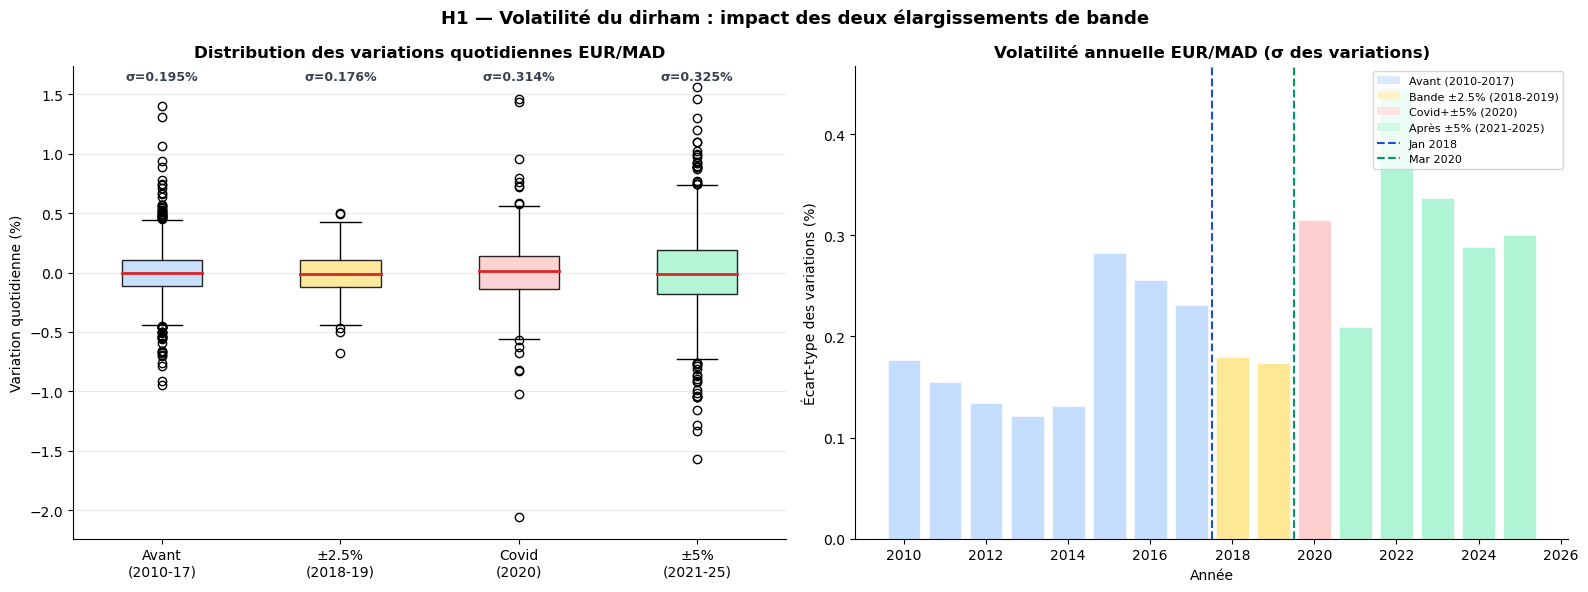

In [76]:
# configuration des graphiques
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("H1 — Volatilité du dirham : impact des deux élargissements de bande",
             fontsize=13, fontweight='bold')

# Gauche — boxplot 4 périodes
ax = axes[0]
data_box = [var_avant, var_bande25, var_covid, var_bande5]
labels   = ['Avant\n(2010-17)', '±2.5%\n(2018-19)',
            'Covid\n(2020)', '±5%\n(2021-25)']
colors_b = list(COLORS_LIGHT.values())

bp = ax.boxplot(data_box, labels=labels, patch_artist=True,
                medianprops=dict(color='#DC2626', linewidth=2))
for patch, color in zip(bp['boxes'], colors_b):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

for i, data in enumerate(data_box, 1):
    ax.text(i, ax.get_ylim()[1] * 0.93,
            f"σ={data.std():.3f}%",
            ha='center', fontsize=9, fontweight='bold', color='#374151')

ax.set_title("Distribution des variations quotidiennes EUR/MAD",
             fontweight='bold')
ax.set_ylabel("Variation quotidienne (%)")
ax.grid(axis='y', color='#E5E5E5', linewidth=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Droite — volatilité annuelle
ax = axes[1]
vol_ann = (eur_mad.set_index('Date')['Variation']
           .resample('Y').std().reset_index())
vol_ann['Year'] = vol_ann['Date'].dt.year
vol_ann = vol_ann[vol_ann['Year'] <= 2025]

bar_colors = []
for y in vol_ann['Year']:
    if y <= 2017:   bar_colors.append(COLORS_LIGHT['avant'])
    elif y <= 2019: bar_colors.append(COLORS_LIGHT['bande25'])
    elif y == 2020: bar_colors.append(COLORS_LIGHT['covid'])
    else:           bar_colors.append(COLORS_LIGHT['bande5'])

bars = ax.bar(vol_ann['Year'], vol_ann['Variation'],
              color=bar_colors, alpha=0.9,
              edgecolor='white', linewidth=0.5)

ax.axvline(2017.5, color='#1D4ED8', linewidth=1.5,
           linestyle='--', label='Jan 2018 — ±2.5%')
ax.axvline(2019.5, color='#059669', linewidth=1.5,
           linestyle='--', label='Mar 2020 — ±5%')

ax.set_title("Volatilité annuelle EUR/MAD (σ des variations)",
             fontweight='bold')
ax.set_ylabel("Écart-type des variations (%)")
ax.set_xlabel("Année")
ax.legend(handles=legend_periodes(), fontsize=8, loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("../visualisation/viz_H1_volatilite.png",
            bbox_inches='tight', dpi=150)
plt.show()

<style>
T1 {
    display: inline-block;
    background: #fef2eb;
    color: #fc8530e1;
    padding: 10px 16px;
    border-radius: 8px; 
    font-size: 20px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Conclusion</T1>

In [77]:
# Conclusion formelle pour H1
p_avant_bande25 = resultats_H1["Avant vs ±2.5% (2018-2019)"]['p']
p_avant_bande5  = resultats_H1["Avant vs Après ±5% (2021-2025)"]['p']
p_bande25_bande5 = resultats_H1["±2.5% vs Après ±5%"]['p']

print("=" * 65)
print("CONCLUSION — H1")
print("=" * 65)
print(f"""
Hypothèse : La volatilité du dirham augmente significativement
            après la réforme de change.

Écarts-types par période :
  Avant    (2010-2017) : {var_avant.std():.4f}%  (référence)
  ±2.5%    (2018-2019) : {var_bande25.std():.4f}%  ({var_bande25.std()/var_avant.std():.2f}x)
  Covid    (2020)      : {var_covid.std():.4f}%  ({var_covid.std()/var_avant.std():.2f}x)
  ±5%      (2021-2025) : {var_bande5.std():.4f}%  ({var_bande5.std()/var_avant.std():.2f}x)

Tests de Levene (α = 0.05) :
  Avant vs ±2.5%  : p = {p_avant_bande25:.6f} → {'Significatif ✓' if p_avant_bande25 < 0.05 else 'Non significatif ✗'}
  Avant vs ±5%    : p = {p_avant_bande5:.6f}  → {'Significatif ✓' if p_avant_bande5 < 0.05 else 'Non significatif ✗'}
  ±2.5% vs ±5%   : p = {p_bande25_bande5:.6f}  → {'Significatif ✓' if p_bande25_bande5 < 0.05 else 'Non significatif ✗'}

Décision finale :
  H1 {'CONFIRMÉE ✓' if p_avant_bande5 < 0.05 else 'NON CONFIRMÉE ✗'}

Notes :
  - 2020 isolé (Covid-19 + élargissement simultanés)
  - L'augmentation progressive de la volatilité entre
    ±2.5% et ±5% reflète l'élargissement graduel de la bande
""")

CONCLUSION — H1

Hypothèse : La volatilité du dirham augmente significativement
            après la réforme de change.

Écarts-types par période :
  Avant    (2010-2017) : 0.1949%  (référence)
  ±2.5%    (2018-2019) : 0.1764%  (0.91x)
  Covid    (2020)      : 0.3142%  (1.61x)
  ±5%      (2021-2025) : 0.3248%  (1.67x)

Tests de Levene (α = 0.05) :
  Avant vs ±2.5%  : p = 0.580493 → Non significatif ✗
  Avant vs ±5%    : p = 0.000000  → Significatif ✓
  ±2.5% vs ±5%   : p = 0.000000  → Significatif ✓

Décision finale :
  H1 CONFIRMÉE ✓

Notes :
  - 2020 isolé (Covid-19 + élargissement simultanés)
  - L'augmentation progressive de la volatilité entre
    ±2.5% et ±5% reflète l'élargissement graduel de la bande



<style>
T1 {
    display: inline-block;
    background: linear-gradient(90deg,#ffb457,#ff7043);
    color: #fff;
    padding: 10px 16px;
    border-radius: 8px;
    font-size: 25px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Test H2 —  La libéralisation du taux de change a un impact positif sur les flux d’IDE à moyen terme</T1>

<style>
T1 {
    display: inline-block;
    background: #f6d98b;
    color: #6b5025;
    padding: 10px 16px;
    border-radius: 8px;
    font-size: 20px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>a- Pour IDE global</T1>

<style>
T1 {
    display: inline-block;
    background: #fef2eb;
    color: #fc8530e1;
    padding: 10px 16px;
    border-radius: 8px; 
    font-size: 20px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Preparation des donnees</T1>

In [47]:
# Extraction et stats descriptives

print("=" * 65)
print("H2 — Impact de la libéralisation sur les flux d'IDE")
print("=" * 65)

ide = dfs_dict['ide_global_cleaned'].copy()

# Extraire IDE par période
def get_ide(debut, fin):
    mask = ide['Year'].between(debut, fin)
    return ide.loc[mask, 'IDE_USD'].dropna().values / 1e9  # en Mrd USD

ide_avant   = get_ide(2010, 2017)
ide_bande25 = get_ide(2018, 2019)
ide_covid   = get_ide(2020, 2020)
ide_bande5  = get_ide(2021, 2025)

print(f"\n{'Période':<30} {'N':>4} {'Moyenne':>10} {'Médiane':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
print("-" * 78)
for label, data in [
    ('Avant (2010-2017)',       ide_avant),
    ('Bande ±2.5% (2018-2019)', ide_bande25),
    ('Covid+±5% (2020)',        ide_covid),
    ('Après ±5% (2021-2025)',   ide_bande5),
]:
    print(f"  {label:<28} {len(data):>4} {data.mean():>10.3f} "
          f"{np.median(data):>10.3f} {data.std():>10.3f} "
          f"{data.min():>10.3f} {data.max():>10.3f}")
print("  (valeurs en Mrd USD)")

H2 — Impact de la libéralisation sur les flux d'IDE

Période                           N    Moyenne    Médiane        Std        Min        Max
------------------------------------------------------------------------------
  Avant (2010-2017)               8      2.697      2.761      0.699      1.241      3.525
  Bande ±2.5% (2018-2019)         2      2.633      2.633      0.912      1.721      3.544
  Covid+±5% (2020)                1      1.419      1.419      0.000      1.419      1.419
  Après ±5% (2021-2025)           4      1.814      1.952      0.508      1.060      2.294
  (valeurs en Mrd USD)


<style>
T1 {
    display: inline-block;
    background: #fef2eb;
    color: #fc8530e1;
    padding: 10px 16px;
    border-radius: 8px; 
    font-size: 20px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Tests statistiques</T1>

In [78]:
alpha = 0.05

# Tests de normalité
print("── Normalité (Shapiro-Wilk) ───────────────────────────────")
for label, data in [
    ('Avant',   ide_avant),
    ('±2.5%',   ide_bande25),
    ('±5%',     ide_bande5),
]:
    if len(data) >= 3:
        stat, p = shapiro(data)
        normal = "Normale" if p > alpha else "Non normale"
        print(f"  {label:<12} : n={len(data)} W={stat:.4f} p={p:.4f} → {normal}")
    else:
        print(f"  {label:<12} : n={len(data)} → trop peu d'obs pour Shapiro")

#  Tests de comparaison 
print("\n── Tests de comparaison des moyennes ──────────────────────")
print(f"\n  {'Comparaison':<35} {'Test':>12} {'Stat':>8} {'p-value':>12} {'Décision':>15}")
print("  " + "-" * 85)

comparaisons_H2 = [
    ("Avant vs ±2.5% (2018-2019)", ide_avant, ide_bande25),
    ("Avant vs ±5%   (2021-2024)", ide_avant, ide_bande5),
    ("±2.5% vs ±5%",               ide_bande25, ide_bande5),
]

resultats_H2 = {}
for label, g1, g2 in comparaisons_H2:
    # Choisir le test selon la taille d'échantillon
    # n petit → Mann-Whitney plus robuste
    stat_mw, p_mw = mannwhitneyu(g1, g2, alternative='two-sided')
    decision = "Rejeter H0 ✓" if p_mw < alpha else "Garder H0 ✗"
    print(f"  {label:<35} {'Mann-Whitney':>12} {stat_mw:>8.1f} {p_mw:>12.4f}   {decision}")
    resultats_H2[label] = {'stat': stat_mw, 'p': p_mw}

# Taille d'effet 
print("\n── Taille d'effet ─────────────────────────────────────────")
print(f"  Moyenne Avant    = {ide_avant.mean():.3f} Mrd USD")
print(f"  Moyenne ±2.5%    = {ide_bande25.mean():.3f} Mrd USD → "
      f"{'hausse' if ide_bande25.mean() > ide_avant.mean() else 'baisse'} "
      f"de {abs(ide_bande25.mean()-ide_avant.mean())/ide_avant.mean()*100:.1f}%")
print(f"  Moyenne ±5%      = {ide_bande5.mean():.3f} Mrd USD → "
      f"{'hausse' if ide_bande5.mean() > ide_avant.mean() else 'baisse'} "
      f"de {abs(ide_bande5.mean()-ide_avant.mean())/ide_avant.mean()*100:.1f}%")
print(f"  Covid 2020       = {ide_covid.mean():.3f} Mrd USD (référence Covid)")

── Normalité (Shapiro-Wilk) ───────────────────────────────
  Avant        : n=8 W=0.9170 p=0.4056 → Normale
  ±2.5%        : n=2 → trop peu d'obs pour Shapiro
  ±5%          : n=5 W=0.8507 p=0.1969 → Normale

── Tests de comparaison des moyennes ──────────────────────

  Comparaison                                 Test     Stat      p-value        Décision
  -------------------------------------------------------------------------------------
  Avant vs ±2.5% (2018-2019)          Mann-Whitney      5.0       0.5333   Garder H0 ✗
  Avant vs ±5%   (2021-2024)          Mann-Whitney      7.0       0.0653   Garder H0 ✗
  ±2.5% vs ±5%                        Mann-Whitney      6.0       0.8571   Garder H0 ✗

── Taille d'effet ─────────────────────────────────────────
  Moyenne Avant    = 34808.975 Mrd USD
  Moyenne ±2.5%    = 40294.000 Mrd USD → hausse de 15.8%
  Moyenne ±5%      = 39998.000 Mrd USD → hausse de 14.9%
  Covid 2020       = 26005.000 Mrd USD (référence Covid)


<style>
T1 {
    display: inline-block;
    background: #fef2eb;
    color: #fc8530e1;
    padding: 10px 16px;
    border-radius: 8px; 
    font-size: 20px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Visualisation</T1>

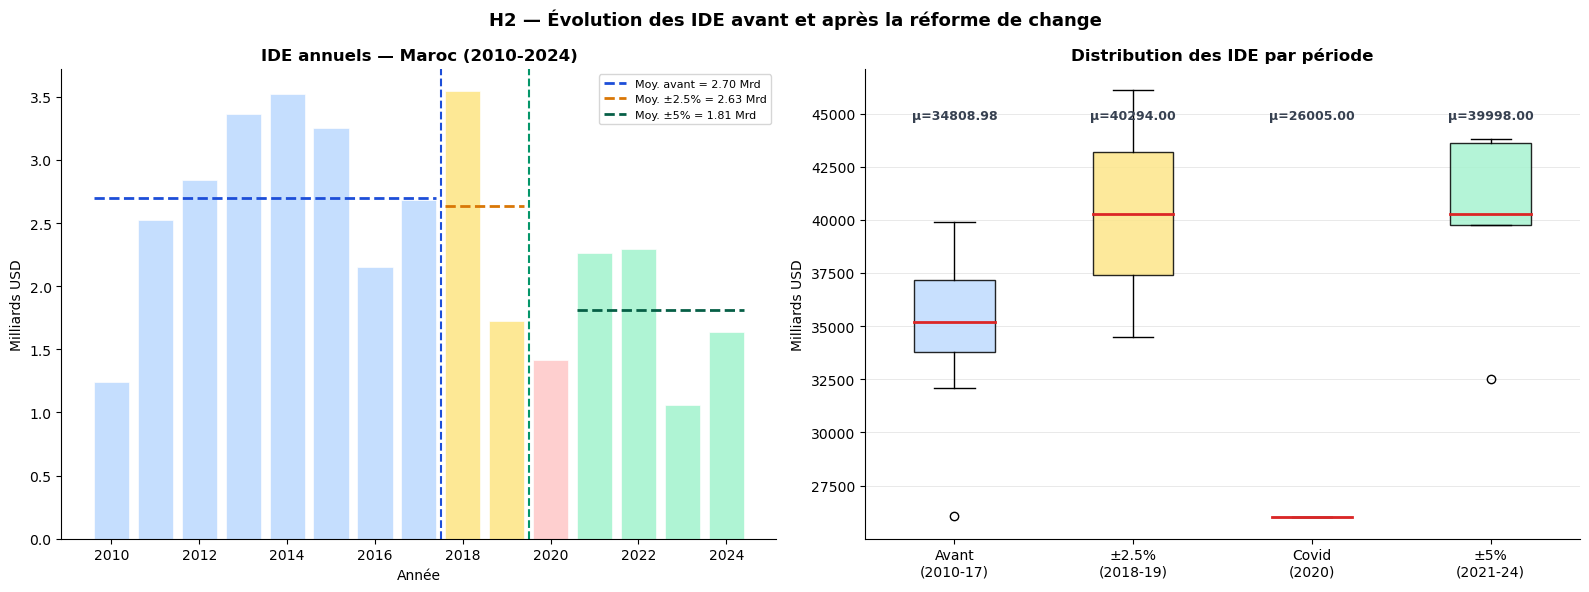

In [79]:
# configuration des graphiques
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("H2 — Évolution des IDE avant et après la réforme de change",
             fontsize=13, fontweight='bold')

# Gauche — IDE annuel en barres
ax = axes[0]
bar_colors = []
for y in ide['Year']:
    if y <= 2017:   bar_colors.append(COLORS_LIGHT['avant'])
    elif y <= 2019: bar_colors.append(COLORS_LIGHT['bande25'])
    elif y == 2020: bar_colors.append(COLORS_LIGHT['covid'])
    else:           bar_colors.append(COLORS_LIGHT['bande5'])

ax.bar(ide['Year'], ide['IDE_USD'] / 1e9,
       color=bar_colors, alpha=0.9,
       edgecolor='white', linewidth=0.5)

# Ligne de moyenne par période
for debut, fin, color, label in [
    (2010, 2017, COLORS['avant'],   'Moy. avant'),
    (2018, 2019, COLORS['bande25'], 'Moy. ±2.5%'),
    (2021, 2024, COLORS['bande5'],  'Moy. ±5%'),
]:
    moy = ide[ide['Year'].between(debut, fin)]['IDE_USD'].mean() / 1e9
    ax.hlines(moy, debut - 0.4, fin + 0.4,
              colors=color, linewidth=2,
              linestyles='--', label=f'{label} = {moy:.2f} Mrd')

ax.axvline(2017.5, color='#1D4ED8', linewidth=1.5, linestyle='--')
ax.axvline(2019.5, color='#059669', linewidth=1.5, linestyle='--')
ax.set_title("IDE annuels — Maroc (2010-2024)", fontweight='bold')
ax.set_ylabel("Milliards USD")
ax.set_xlabel("Année")
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Droite — boxplot par période
ax = axes[1]
data_box = [ide_avant, ide_bande25, ide_covid, ide_bande5]
labels   = ['Avant\n(2010-17)', '±2.5%\n(2018-19)',
            'Covid\n(2020)', '±5%\n(2021-24)']

bp = ax.boxplot(data_box, labels=labels, patch_artist=True,
                medianprops=dict(color='#DC2626', linewidth=2))
for patch, color in zip(bp['boxes'], list(COLORS_LIGHT.values())):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

for i, data in enumerate(data_box, 1):
    ax.text(i, ax.get_ylim()[1] * 0.95,
            f"μ={data.mean():.2f}",
            ha='center', fontsize=9,
            fontweight='bold', color='#374151')

ax.set_title("Distribution des IDE par période", fontweight='bold')
ax.set_ylabel("Milliards USD")
ax.grid(axis='y', color='#E5E5E5', linewidth=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("../visualisation/viz_H2_ide.png",
            bbox_inches='tight', dpi=150)
plt.show()

<style>
T1 {
    display: inline-block;
    background: #fef2eb;
    color: #fc8530e1;
    padding: 10px 16px;
    border-radius: 8px; 
    font-size: 20px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Conclusion</T1>

In [80]:
# Conclusion formelle pour H2
p_avant_bande25 = resultats_H2["Avant vs ±2.5% (2018-2019)"]['p']
p_avant_bande5  = resultats_H2["Avant vs ±5%   (2021-2024)"]['p']

print("=" * 65)
print("CONCLUSION — H2")
print("=" * 65)
print(f"""
Hypothèse : La libéralisation du taux de change a un impact
            positif sur les flux d'IDE à moyen terme.

Moyennes par période :
  Avant    (2010-2017) : {ide_avant.mean():.3f} Mrd USD  (référence)
  ±2.5%    (2018-2019) : {ide_bande25.mean():.3f} Mrd USD
  Covid    (2020)      : {ide_covid.mean():.3f} Mrd USD
  ±5%      (2021-2024) : {ide_bande5.mean():.3f} Mrd USD

Tests Mann-Whitney (α = 0.05) :
  Avant vs ±2.5% : p = {p_avant_bande25:.4f} → {'Significatif ✓' if p_avant_bande25 < alpha else 'Non significatif ✗'}
  Avant vs ±5%   : p = {p_avant_bande5:.4f}  → {'Significatif ✓' if p_avant_bande5 < alpha else 'Non significatif ✗'}

Décision finale :
  H2 {'CONFIRMÉE ✓' if p_avant_bande5 < alpha and ide_bande5.mean() > ide_avant.mean() else 'NON CONFIRMÉE ✗'}

Limites :
  - Petit échantillon (n=8 avant, n=4 après) → puissance limitée
  - La baisse des IDE commence en 2015, avant la réforme
  - Facteurs confondants : Covid 2020, contexte mondial
  - Conclusion prudente — la réforme seule ne peut pas
    expliquer l'évolution des IDE
""")

CONCLUSION — H2

Hypothèse : La libéralisation du taux de change a un impact
            positif sur les flux d'IDE à moyen terme.

Moyennes par période :
  Avant    (2010-2017) : 34808.975 Mrd USD  (référence)
  ±2.5%    (2018-2019) : 40294.000 Mrd USD
  Covid    (2020)      : 26005.000 Mrd USD
  ±5%      (2021-2024) : 39998.000 Mrd USD

Tests Mann-Whitney (α = 0.05) :
  Avant vs ±2.5% : p = 0.5333 → Non significatif ✗
  Avant vs ±5%   : p = 0.0653  → Non significatif ✗

Décision finale :
  H2 NON CONFIRMÉE ✗

Limites :
  - Petit échantillon (n=8 avant, n=4 après) → puissance limitée
  - La baisse des IDE commence en 2015, avant la réforme
  - Facteurs confondants : Covid 2020, contexte mondial
  - Conclusion prudente — la réforme seule ne peut pas
    expliquer l'évolution des IDE



<style>
T1 {
    display: inline-block;
    background: #f6d98b;
    color: #6b5025;
    padding: 10px 16px;
    border-radius: 8px;
    font-size: 20px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>b- Pour IDE avec analyse sectorielle</T1>

In [81]:
# Analyse par secteur
ide_s = dfs_dict['ide_secteur_cleaned'].copy()

SECTEURS = [c for c in ide_s.columns if c not in ['Year', 'TOTAL']]

print("=" * 65)
print("H2 — Impact de la libéralisation sur les IDE (par secteur)")
print("=" * 65)

# Extraire TOTAL par période
def get_ide_s(debut, fin):
    return ide_s[ide_s['Year'].between(debut, fin)]['TOTAL'].values

ide_avant   = get_ide_s(2010, 2017)
ide_bande25 = get_ide_s(2018, 2019)
ide_covid   = get_ide_s(2020, 2020)
ide_bande5  = get_ide_s(2021, 2025)

print(f"\n{'Période':<30} {'N':>4} {'Moyenne':>12} {'Médiane':>12} {'Std':>10}")
print("-" * 70)
for label, data in [
    ('Avant (2010-2017)',        ide_avant),
    ('Bande ±2.5% (2018-2019)', ide_bande25),
    ('Covid+±5% (2020)',         ide_covid),
    ('Après ±5% (2021-2025)',    ide_bande5),
]:
    print(f"  {label:<28} {len(data):>4} "
          f"{data.mean():>12.1f} {np.median(data):>12.1f} "
          f"{data.std():>10.1f}")
print("  (valeurs en Millions MAD)")

# Évolution par secteur entre avant et après
print(f"\n── Évolution des secteurs : Avant vs Après ±5% ────────────")
print(f"  {'Secteur':<25} {'Moy Avant':>12} {'Moy ±5%':>12} {'Variation':>12}")
print("  " + "-" * 65)

evolutions = []
for s in SECTEURS:
    moy_avant = ide_s[ide_s['Year'].between(2010, 2017)][s].mean()
    moy_bande5 = ide_s[ide_s['Year'].between(2021, 2025)][s].mean()
    var = (moy_bande5 - moy_avant) / moy_avant * 100
    evolutions.append((s, moy_avant, moy_bande5, var))

evolutions.sort(key=lambda x: x[3], reverse=True)
for s, ma, mb, v in evolutions:
    signe = "▲" if v > 0 else "▼"
    print(f"  {s:<25} {ma:>12.1f} {mb:>12.1f} {signe}{abs(v):>10.1f}%")

H2 — Impact de la libéralisation sur les IDE (par secteur)

Période                           N      Moyenne      Médiane        Std
----------------------------------------------------------------------
  Avant (2010-2017)               8      34809.0      35209.8     4059.9
  Bande ±2.5% (2018-2019)         2      40294.0      40294.0     5805.0
  Covid+±5% (2020)                1      26005.0      26005.0        0.0
  Après ±5% (2021-2025)           5      39998.0      40297.0     4082.4
  (valeurs en Millions MAD)

── Évolution des secteurs : Avant vs Après ±5% ────────────
  Secteur                      Moy Avant      Moy ±5%    Variation
  -----------------------------------------------------------------
  Agriculture                      207.7        753.0 ▲     262.5%
  Transports                       634.5       1672.6 ▲     163.6%
  Pêche                             23.2         58.0 ▲     150.4%
  Industrie                       8688.2      14229.6 ▲      63.8%
  Autres ser

<style>
T1 {
    display: inline-block;
    background: #fef2eb;
    color: #fc8530e1;
    padding: 10px 16px;
    border-radius: 8px; 
    font-size: 20px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Tests statistiques</T1>

In [82]:
# Tests de comparaison par secteur
alpha = 0.05

print("\n── Tests Mann-Whitney — TOTAL IDE ─────────────────────────")
print(f"\n  {'Comparaison':<35} {'Stat':>8} {'p-value':>12} {'Décision':>15}")
print("  " + "-" * 75)

comparaisons_H2 = [
    ("Avant vs ±2.5% (2018-2019)", ide_avant, ide_bande25),
    ("Avant vs ±5%   (2021-2025)", ide_avant, ide_bande5),
    ("±2.5% vs ±5%",               ide_bande25, ide_bande5),
]

resultats_H2 = {}
for label, g1, g2 in comparaisons_H2:
    stat, p = mannwhitneyu(g1, g2, alternative='two-sided')
    decision = "Rejeter H0 ✓" if p < alpha else "Garder H0 ✗"
    print(f"  {label:<35} {stat:>8.1f} {p:>12.4f}   {decision}")
    resultats_H2[label] = {'stat': stat, 'p': p}

# Test par secteur — Avant vs Après ±5%
print(f"\n── Tests par secteur : Avant vs Après ±5% ─────────────────")
print(f"  {'Secteur':<25} {'p-value':>12} {'Décision':>15} {'Direction':>12}")
print("  " + "-" * 68)

for s in SECTEURS:
    g1 = ide_s[ide_s['Year'].between(2010, 2017)][s].values
    g2 = ide_s[ide_s['Year'].between(2021, 2025)][s].values
    try:
        stat, p = mannwhitneyu(g1, g2, alternative='two-sided')
        decision = "Sig. ✓" if p < alpha else "Non sig. ✗"
        direction = "↑ Hausse" if g2.mean() > g1.mean() else "↓ Baisse"
        print(f"  {s:<25} {p:>12.4f}   {decision:<15} {direction:>12}")
    except:
        print(f"  {s:<25} {'N/A':>12}")


── Tests Mann-Whitney — TOTAL IDE ─────────────────────────

  Comparaison                             Stat      p-value        Décision
  ---------------------------------------------------------------------------
  Avant vs ±2.5% (2018-2019)               5.0       0.5333   Garder H0 ✗
  Avant vs ±5%   (2021-2025)               7.0       0.0653   Garder H0 ✗
  ±2.5% vs ±5%                             6.0       0.8571   Garder H0 ✗

── Tests par secteur : Avant vs Après ±5% ─────────────────
  Secteur                        p-value        Décision    Direction
  --------------------------------------------------------------------
  Agriculture                     0.0016   Sig. ✓              ↑ Hausse
  Assurance                       0.8329   Non sig. ✗          ↓ Baisse
  Autres services                 0.0186   Sig. ✓              ↑ Hausse
  Banque                          0.5237   Non sig. ✗          ↓ Baisse
  Commerce                        0.2844   Non sig. ✗          ↑ Hausse


<style>
T1 {
    display: inline-block;
    background: #fef2eb;
    color: #fc8530e1;
    padding: 10px 16px;
    border-radius: 8px; 
    font-size: 20px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Visualisation</T1>

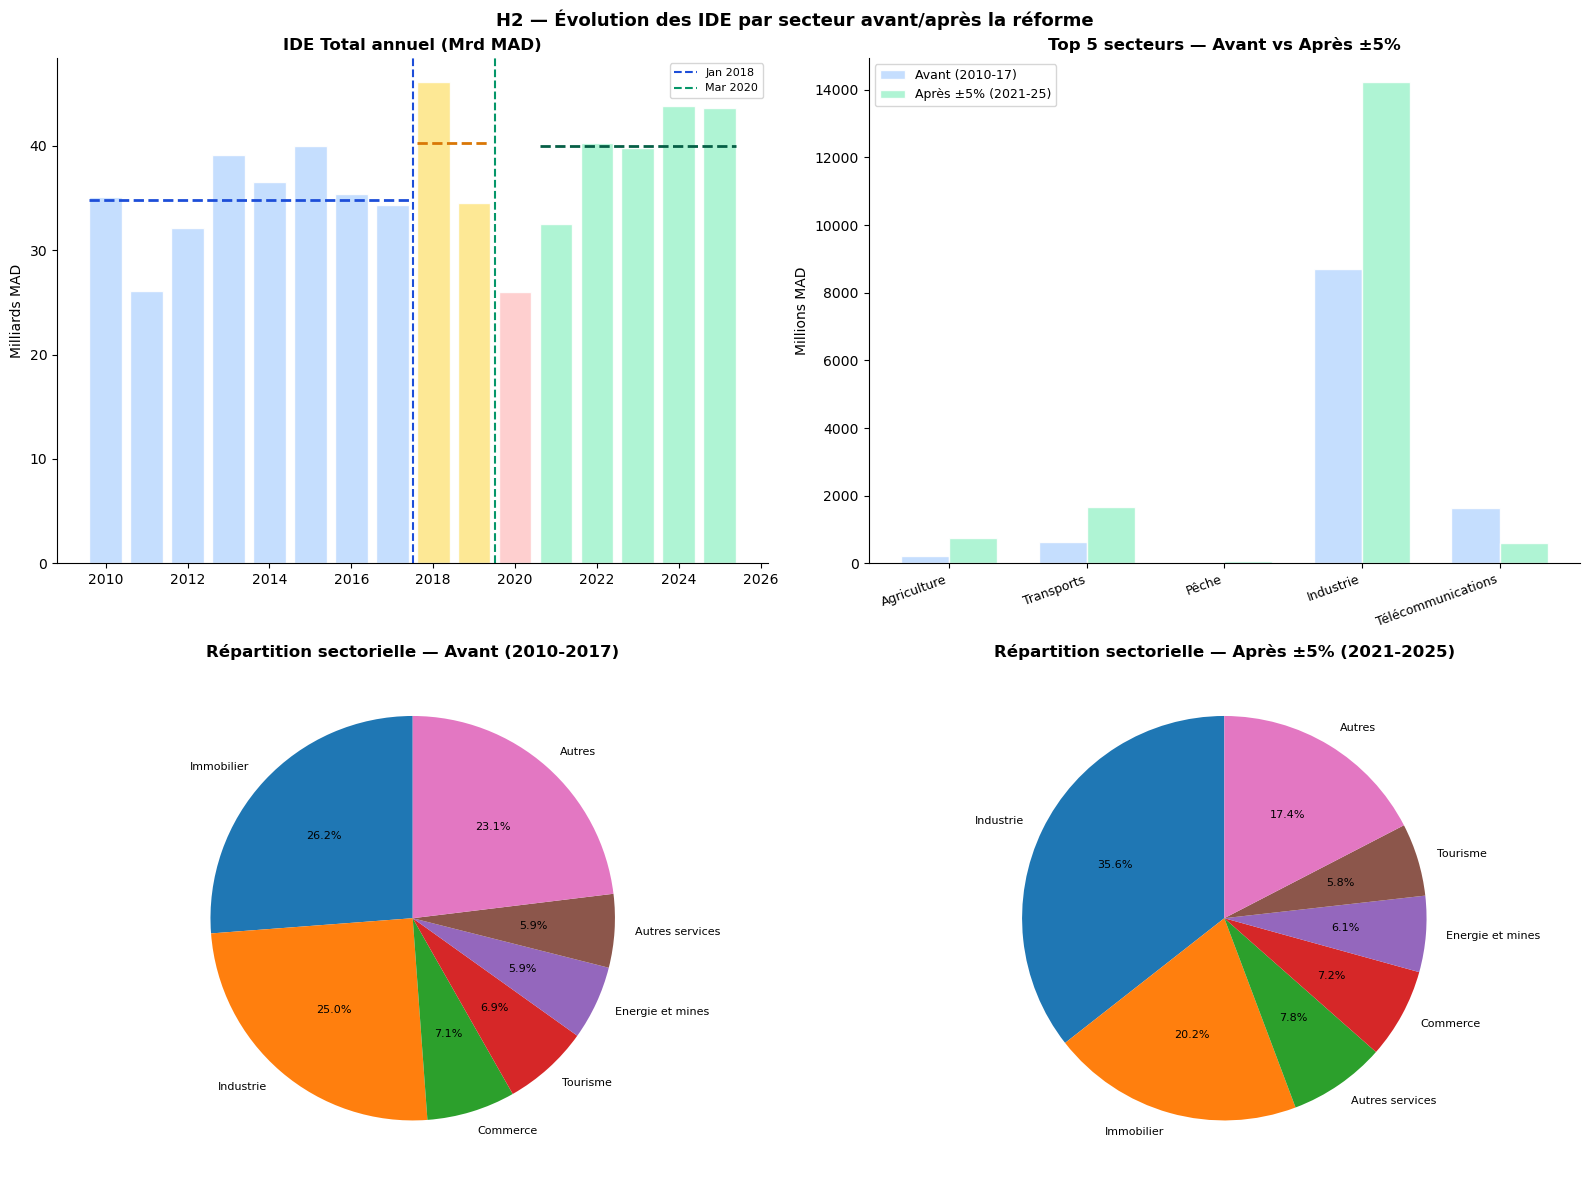

In [83]:
# Configuration des graphiques
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("H2 — Évolution des IDE par secteur avant/après la réforme",
             fontsize=13, fontweight='bold')

# Haut gauche — TOTAL annuel
ax = axes[0, 0]
bar_colors = []
for y in ide_s['Year']:
    if y <= 2017:   bar_colors.append(COLORS_LIGHT['avant'])
    elif y <= 2019: bar_colors.append(COLORS_LIGHT['bande25'])
    elif y == 2020: bar_colors.append(COLORS_LIGHT['covid'])
    else:           bar_colors.append(COLORS_LIGHT['bande5'])

ax.bar(ide_s['Year'], ide_s['TOTAL'] / 1000,
       color=bar_colors, alpha=0.9, edgecolor='white')

for debut, fin, color in [
    (2010, 2017, COLORS['avant']),
    (2018, 2019, COLORS['bande25']),
    (2021, 2025, COLORS['bande5']),
]:
    moy = ide_s[ide_s['Year'].between(debut, fin)]['TOTAL'].mean() / 1000
    ax.hlines(moy, debut - 0.4, fin + 0.4,
              colors=color, linewidth=2, linestyles='--')

ax.axvline(2017.5, color='#1D4ED8', linewidth=1.5, linestyle='--', label='Jan 2018')
ax.axvline(2019.5, color='#059669', linewidth=1.5, linestyle='--', label='Mar 2020')
ax.set_title("IDE Total annuel (Mrd MAD)", fontweight='bold')
ax.set_ylabel("Milliards MAD")
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Haut droite — Top 5 secteurs évolution
ax = axes[0, 1]
top5 = sorted(evolutions, key=lambda x: abs(x[3]), reverse=True)[:5]
secteurs_top = [e[0] for e in top5]
moy_avant_top = [e[1] for e in top5]
moy_bande5_top = [e[2] for e in top5]

x = np.arange(len(secteurs_top))
w = 0.35
ax.bar(x - w/2, moy_avant_top, w,
       color=COLORS_LIGHT['avant'], label='Avant (2010-17)',
       edgecolor='white', alpha=0.9)
ax.bar(x + w/2, moy_bande5_top, w,
       color=COLORS_LIGHT['bande5'], label='Après ±5% (2021-25)',
       edgecolor='white', alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(secteurs_top, rotation=20, ha='right', fontsize=9)
ax.set_title("Top 5 secteurs — Avant vs Après ±5%", fontweight='bold')
ax.set_ylabel("Millions MAD")
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Bas gauche — Répartition sectorielle Avant
ax = axes[1, 0]
moy_avant_sect = {s: ide_s[ide_s['Year'].between(2010,2017)][s].mean()
                  for s in SECTEURS}
top_secteurs = sorted(moy_avant_sect, key=moy_avant_sect.get, reverse=True)[:6]
autres = sum(v for k,v in moy_avant_sect.items() if k not in top_secteurs)
vals = [moy_avant_sect[s] for s in top_secteurs] + [autres]
lbls = top_secteurs + ['Autres']
ax.pie(vals, labels=lbls, autopct='%1.1f%%',
       startangle=90, textprops={'fontsize': 8})
ax.set_title("Répartition sectorielle — Avant (2010-2017)", fontweight='bold')

# Bas droite — Répartition sectorielle Après ±5%
ax = axes[1, 1]
moy_bande5_sect = {s: ide_s[ide_s['Year'].between(2021,2025)][s].mean()
                   for s in SECTEURS}
top_secteurs2 = sorted(moy_bande5_sect, key=moy_bande5_sect.get, reverse=True)[:6]
autres2 = sum(v for k,v in moy_bande5_sect.items() if k not in top_secteurs2)
vals2 = [moy_bande5_sect[s] for s in top_secteurs2] + [autres2]
lbls2 = top_secteurs2 + ['Autres']
ax.pie(vals2, labels=lbls2, autopct='%1.1f%%',
       startangle=90, textprops={'fontsize': 8})
ax.set_title("Répartition sectorielle — Après ±5% (2021-2025)", fontweight='bold')

plt.tight_layout()
plt.savefig("../visualisation/viz_H2_ide_secteur.png",
            bbox_inches='tight', dpi=150)
plt.show()

<style>
T1 {
    display: inline-block;
    background: #fef2eb;
    color: #fc8530e1;
    padding: 10px 16px;
    border-radius: 8px; 
    font-size: 20px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Conclusion</T1>

In [84]:
# Conclusion formelle pour H2 (secteur)
p_avant_bande5 = resultats_H2["Avant vs ±5%   (2021-2025)"]['p']
p_avant_bande25 = resultats_H2["Avant vs ±2.5% (2018-2019)"]['p']

print("=" * 65)
print("CONCLUSION — H2")
print("=" * 65)
print(f"""
Hypothèse : La libéralisation a un impact positif sur les IDE.

IDE Total par période (Millions MAD) :
  Avant    (2010-2017) : {ide_avant.mean():>8.1f}  (référence)
  ±2.5%    (2018-2019) : {ide_bande25.mean():>8.1f}
  Covid    (2020)      : {ide_covid.mean():>8.1f}
  ±5%      (2021-2025) : {ide_bande5.mean():>8.1f}
  Variation Avant→±5%  : {(ide_bande5.mean()-ide_avant.mean())/ide_avant.mean()*100:>+.1f}%

Tests Mann-Whitney (α = 0.05) :
  Avant vs ±2.5% : p = {p_avant_bande25:.4f} → {'Significatif ✓' if p_avant_bande25 < alpha else 'Non significatif ✗'}
  Avant vs ±5%   : p = {p_avant_bande5:.4f}  → {'Significatif ✓' if p_avant_bande5 < alpha else 'Non significatif ✗'}

Secteurs les plus dynamiques après la réforme :
""")

for s, ma, mb, v in evolutions[:3]:
    print(f"  ▲ {s:<20} : +{v:.1f}%")
print()
for s, ma, mb, v in evolutions[-3:]:
    print(f"  ▼ {s:<20} : {v:.1f}%")

print(f"""
Décision : H2 {'CONFIRMÉE ✓' if p_avant_bande5 < alpha and
               ide_bande5.mean() > ide_avant.mean()
               else 'NON CONFIRMÉE ✗'}

Limites :
  - Données 2024* et 2025 provisoires
  - Petit échantillon par période (n=8 avant, n=5 après)
  - Facteurs confondants non contrôlés (Covid, conjoncture)
""")

CONCLUSION — H2

Hypothèse : La libéralisation a un impact positif sur les IDE.

IDE Total par période (Millions MAD) :
  Avant    (2010-2017) :  34809.0  (référence)
  ±2.5%    (2018-2019) :  40294.0
  Covid    (2020)      :  26005.0
  ±5%      (2021-2025) :  39998.0
  Variation Avant→±5%  : +14.9%

Tests Mann-Whitney (α = 0.05) :
  Avant vs ±2.5% : p = 0.5333 → Non significatif ✗
  Avant vs ±5%   : p = 0.0653  → Non significatif ✗

Secteurs les plus dynamiques après la réforme :

  ▲ Agriculture          : +262.5%
  ▲ Transports           : +163.6%
  ▲ Pêche                : +150.4%

  ▼ Grands travaux       : -34.6%
  ▼ Assurance            : -37.6%
  ▼ Télécommunications   : -62.8%

Décision : H2 NON CONFIRMÉE ✗

Limites :
  - Données 2024* et 2025 provisoires
  - Petit échantillon par période (n=8 avant, n=5 après)
  - Facteurs confondants non contrôlés (Covid, conjoncture)



<style>
T1 {
    display: inline-block;
    background: linear-gradient(90deg,#ffb457,#ff7043);
    color: #fff;
    padding: 10px 16px;
    border-radius: 8px;
    font-size: 25px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Test H3 —  La flexibilité accrue du taux de change influence la balance commerciale marocaine </T1>

<style>
T1 {
    display: inline-block;
    background: #fef2eb;
    color: #fc8530e1;
    padding: 10px 16px;
    border-radius: 8px; 
    font-size: 20px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Preparation de donnees</T1>

In [85]:
#  Stats descriptives
print("=" * 65)
print("H3 — Impact sur la balance commerciale")
print("=" * 65)

ice = dfs_dict['ice_global_cleaned'].copy()
macro = dfs_dict['macro_cleaned'].copy()

# Calculer balance et taux de couverture
ice['balance']    = ice['value_exports'] - ice['value_imports']
ice['tx_couv']    = (ice['value_exports'] / ice['value_imports']) * 100
ice['exports_mrd'] = ice['value_exports'] / 1e9
ice['imports_mrd'] = ice['value_imports'] / 1e9
ice['balance_mrd'] = ice['balance'] / 1e9

# Extraire par période
def get_ice(col, debut, fin):
    return ice[ice['year'].between(debut, fin)][col].values

def get_macro(col, debut, fin):
    return macro[macro['year'].between(debut, fin)][col].values

print(f"\n{'Période':<30} {'N':>4} {'Exports':>10} {'Imports':>10} {'Balance':>10} {'Tx Couv':>10}")
print("-" * 68)
for label, (debut, fin) in PERIODES.items():
    exp  = get_ice('exports_mrd', debut, fin).mean()
    imp  = get_ice('imports_mrd', debut, fin).mean()
    bal  = get_ice('balance_mrd', debut, fin).mean()
    tc   = get_ice('tx_couv',     debut, fin).mean()
    n    = len(get_ice('exports_mrd', debut, fin))
    print(f"  {label:<28} {n:>4} {exp:>10.2f} {imp:>10.2f} "
          f"{bal:>10.2f} {tc:>10.2f}%")
print("  (Exports/Imports/Balance en Mrd USD | Tx Couv en %)")

# Solde courant
print(f"\n── Solde courant (% PIB) par période ───────────────────────")
print(f"  {'Période':<30} {'Moy':>8} {'Min':>8} {'Max':>8}")
print("  " + "-" * 48)
for label, (debut, fin) in PERIODES.items():
    s = get_macro('current_account', debut, fin)
    print(f"  {label:<30} {s.mean():>8.2f} {s.min():>8.2f} {s.max():>8.2f}")

H3 — Impact sur la balance commerciale

Période                           N    Exports    Imports    Balance    Tx Couv
--------------------------------------------------------------------
  Avant (2010-2017)               8      34.57      46.82     -12.25      74.03%
  Bande ±2.5% (2018-2019)         2      43.52      54.66     -11.15      79.63%
  Covid + ±5% (2020)              1      37.37      46.17      -8.80      80.93%
  Après ±5% (2021-2025)           4      58.79      72.15     -13.36      81.27%
  (Exports/Imports/Balance en Mrd USD | Tx Couv en %)

── Solde courant (% PIB) par période ───────────────────────
  Période                             Moy      Min      Max
  ------------------------------------------------
  Avant (2010-2017)                 -5.15    -8.95    -1.96
  Bande ±2.5% (2018-2019)           -4.15    -4.87    -3.42
  Covid + ±5% (2020)                -1.13    -1.13    -1.13
  Après ±5% (2021-2025)             -2.06    -3.66    -1.05


<style>
T1 {
    display: inline-block;
    background: #fef2eb;
    color: #fc8530e1;
    padding: 10px 16px;
    border-radius: 8px; 
    font-size: 20px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Tests statistiques</T1>

In [86]:
# Tests de comparaison
alpha = 0.05

# Extraire les séries
bal_avant   = get_ice('balance_mrd', 2010, 2017)
bal_bande25 = get_ice('balance_mrd', 2018, 2019)
bal_covid   = get_ice('balance_mrd', 2020, 2020)
bal_bande5  = get_ice('balance_mrd', 2021, 2025)

tc_avant    = get_ice('tx_couv', 2010, 2017)
tc_bande5   = get_ice('tx_couv', 2021, 2025)

sc_avant    = get_macro('current_account', 2010, 2017)
sc_bande25  = get_macro('current_account', 2018, 2019)
sc_covid    = get_macro('current_account', 2020, 2020)
sc_bande5   = get_macro('current_account', 2021, 2025)

# Tests sur la balance commerciale
print("── Tests Mann-Whitney — Balance commerciale ───────────────")
print(f"\n  {'Comparaison':<35} {'Stat':>8} {'p-value':>12} {'Décision':>15}")
print("  " + "-" * 75)

comparaisons_bal = [
    ("Avant vs ±2.5% (2018-2019)", bal_avant, bal_bande25),
    ("Avant vs ±5%   (2021-2025)", bal_avant, bal_bande5),
    ("Avant vs Covid (2020)",       bal_avant, bal_covid),
]

resultats_H3_bal = {}
for label, g1, g2 in comparaisons_bal:
    stat, p = mannwhitneyu(g1, g2, alternative='two-sided')
    decision = "Rejeter H0 ✓" if p < alpha else "Garder H0 ✗"
    print(f"  {label:<35} {stat:>8.1f} {p:>12.4f}   {decision}")
    resultats_H3_bal[label] = {'stat': stat, 'p': p}

# Tests sur le solde courant
print("\n── Tests Mann-Whitney — Solde courant (% PIB) ─────────────")
print(f"\n  {'Comparaison':<35} {'Stat':>8} {'p-value':>12} {'Décision':>15}")
print("  " + "-" * 75)

comparaisons_sc = [
    ("Avant vs ±2.5% (2018-2019)", sc_avant, sc_bande25),
    ("Avant vs ±5%   (2021-2025)", sc_avant, sc_bande5),
    ("Avant vs Covid (2020)",       sc_avant, sc_covid),
]

resultats_H3_sc = {}
for label, g1, g2 in comparaisons_sc:
    stat, p = mannwhitneyu(g1, g2, alternative='two-sided')
    decision = "Rejeter H0 ✓" if p < alpha else "Garder H0 ✗"
    print(f"  {label:<35} {stat:>8.1f} {p:>12.4f}   {decision}")
    resultats_H3_sc[label] = {'stat': stat, 'p': p}

# Tests sur le taux de couverture
print("\n── Tests Mann-Whitney — Taux de couverture ────────────────")
tc_bande25 = get_ice('tx_couv', 2018, 2019)
stat_tc, p_tc = mannwhitneyu(tc_avant, tc_bande5, alternative='two-sided')
print(f"  Avant vs ±5% : stat={stat_tc:.1f} p={p_tc:.4f} → "
      f"{'Rejeter H0 ✓' if p_tc < alpha else 'Garder H0 ✗'}")

# Régression linéaire : tendance temporelle
print("\n── Régression — Tendance du solde courant ─────────────────")
slope, intercept, r, p_reg, se = linregress(macro['year'], macro['current_account'])
print(f"  Pente    : {slope:.4f} % PIB / an")
print(f"  R²       : {r**2:.4f}")
print(f"  p-value  : {p_reg:.6f}")
print(f"  → Le solde courant s'améliore de {slope:.3f}% PIB par an")

── Tests Mann-Whitney — Balance commerciale ───────────────

  Comparaison                             Stat      p-value        Décision
  ---------------------------------------------------------------------------
  Avant vs ±2.5% (2018-2019)               6.0       0.7111   Garder H0 ✗
  Avant vs ±5%   (2021-2025)              19.0       0.6828   Garder H0 ✗
  Avant vs Covid (2020)                    1.0       0.4444   Garder H0 ✗

── Tests Mann-Whitney — Solde courant (% PIB) ─────────────

  Comparaison                             Stat      p-value        Décision
  ---------------------------------------------------------------------------
  Avant vs ±2.5% (2018-2019)               6.0       0.7111   Garder H0 ✗
  Avant vs ±5%   (2021-2025)               3.0       0.0283   Rejeter H0 ✓
  Avant vs Covid (2020)                    0.0       0.2222   Garder H0 ✗

── Tests Mann-Whitney — Taux de couverture ────────────────
  Avant vs ±5% : stat=3.0 p=0.0283 → Rejeter H0 ✓

── Régressio

<style>
T1 {
    display: inline-block;
    background: #fef2eb;
    color: #fc8530e1;
    padding: 10px 16px;
    border-radius: 8px; 
    font-size: 20px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Visualisation</T1>

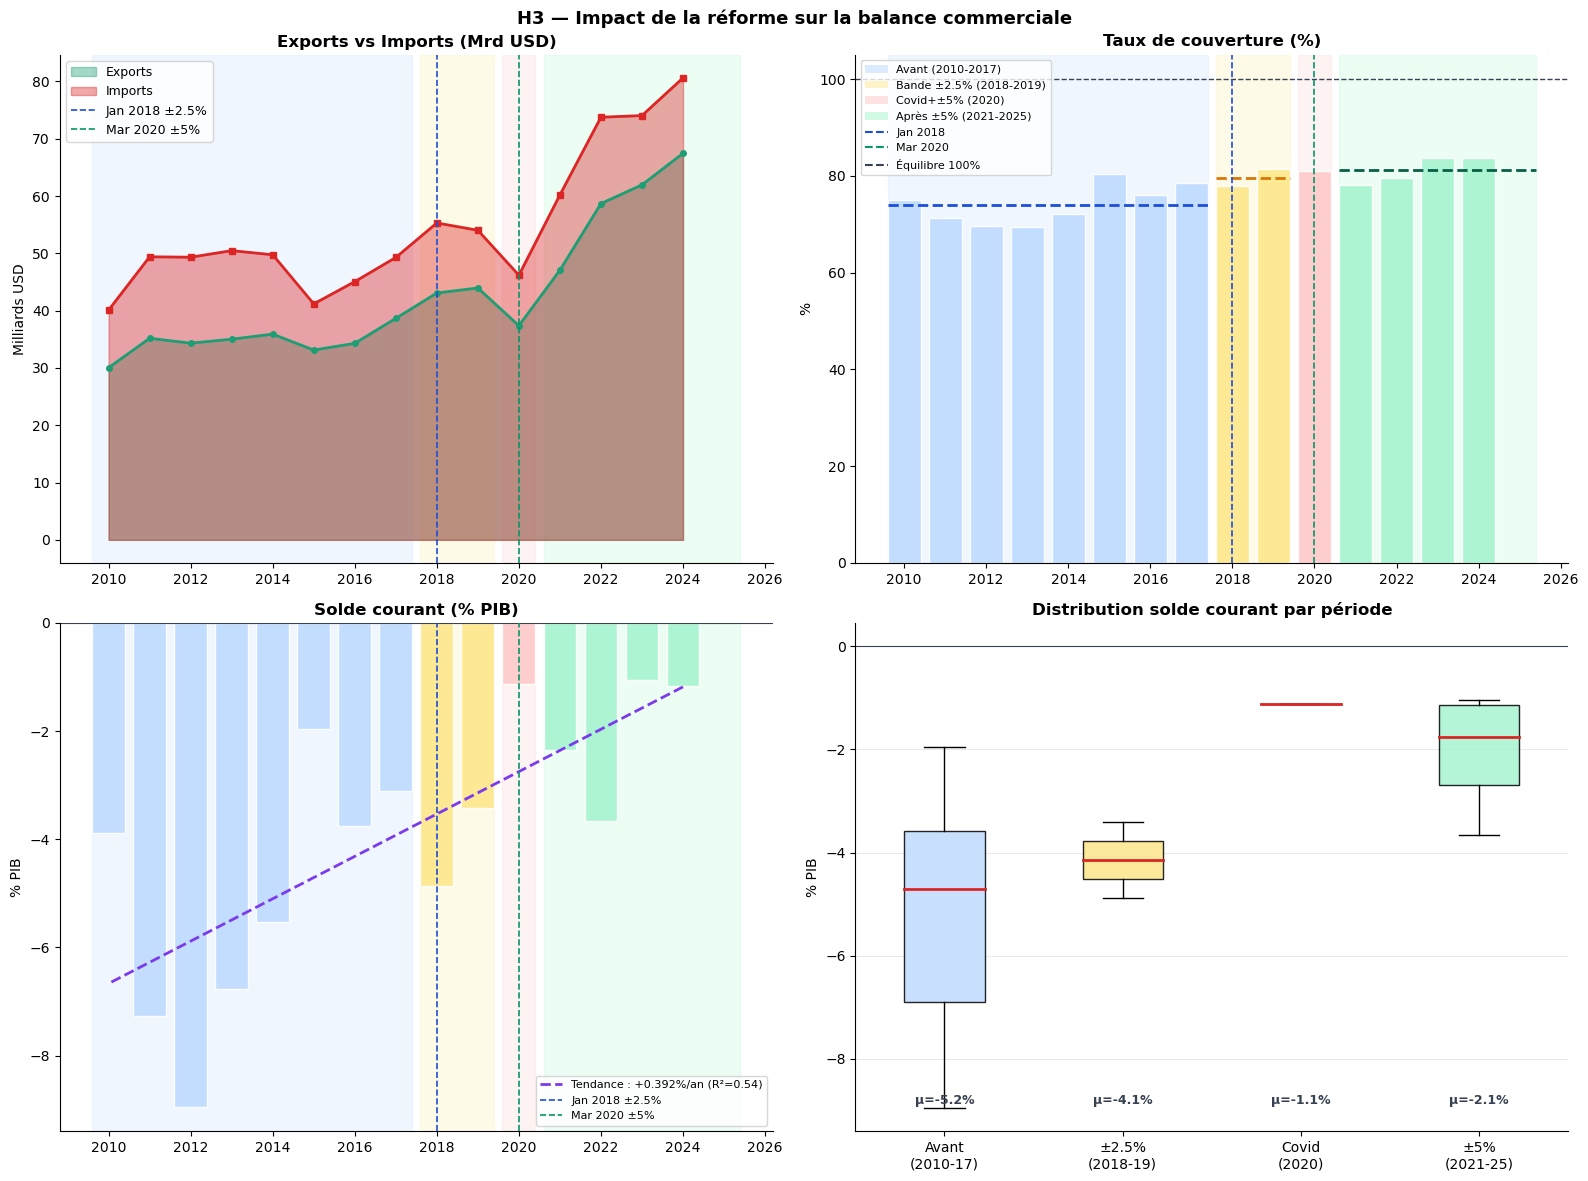

In [87]:
# Configuration des graphiques
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("H3 — Impact de la réforme sur la balance commerciale",
             fontsize=13, fontweight='bold')

# Haut gauche — Exports et Imports annuels
ax = axes[0, 0]
ax.fill_between(ice['year'], ice['exports_mrd'],
                alpha=0.4, color='#1D9E75', label='Exports')
ax.fill_between(ice['year'], ice['imports_mrd'],
                alpha=0.4, color='#DC2626', label='Imports')
ax.plot(ice['year'], ice['exports_mrd'],
        color='#1D9E75', linewidth=2, marker='o', markersize=4)
ax.plot(ice['year'], ice['imports_mrd'],
        color='#DC2626', linewidth=2, marker='s', markersize=4)
add_bands(ax, is_date=False)
ax.set_title("Exports vs Imports (Mrd USD)", fontweight='bold')
ax.set_ylabel("Milliards USD")
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Haut droite — Taux de couverture
ax = axes[0, 1]
bar_colors = []
for y in ice['year']:
    if y <= 2017:   bar_colors.append(COLORS_LIGHT['avant'])
    elif y <= 2019: bar_colors.append(COLORS_LIGHT['bande25'])
    elif y == 2020: bar_colors.append(COLORS_LIGHT['covid'])
    else:           bar_colors.append(COLORS_LIGHT['bande5'])

ax.bar(ice['year'], ice['tx_couv'],
       color=bar_colors, alpha=0.9, edgecolor='white')
ax.axhline(100, color='#374151', linewidth=1,
           linestyle='--', label='Équilibre (100%)')

for label, (debut, fin), color in [
    ('Avant',  (2010,2017), COLORS['avant']),
    ('±2.5%',  (2018,2019), COLORS['bande25']),
    ('±5%',    (2021,2025), COLORS['bande5']),
]:
    moy = ice[ice['year'].between(debut, fin)]['tx_couv'].mean()
    ax.hlines(moy, debut-0.4, fin+0.4, colors=color,
              linewidth=2, linestyles='--')

add_bands(ax, is_date=False)
ax.set_title("Taux de couverture (%)", fontweight='bold')
ax.set_ylabel("%")
ax.legend(handles=legend_periodes() + [
    plt.Line2D([0],[0], color='#374151', linestyle='--', label='Équilibre 100%')
], fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Bas gauche — Solde courant % PIB
ax = axes[1, 0]
sc_colors = []
for y in macro['year']:
    if y <= 2017:   sc_colors.append(COLORS_LIGHT['avant'])
    elif y <= 2019: sc_colors.append(COLORS_LIGHT['bande25'])
    elif y == 2020: sc_colors.append(COLORS_LIGHT['covid'])
    else:           sc_colors.append(COLORS_LIGHT['bande5'])

ax.bar(macro['year'], macro['current_account'],
       color=sc_colors, alpha=0.9, edgecolor='white')
ax.axhline(0, color='#374151', linewidth=0.8, linestyle='-')

# Ligne de tendance
x_trend = np.array(macro['year'])
y_trend = slope * x_trend + intercept
ax.plot(x_trend, y_trend, color='#7C3AED',
        linewidth=2, linestyle='--',
        label=f'Tendance : +{slope:.3f}%/an (R²={r**2:.2f})')

add_bands(ax, is_date=False)
ax.set_title("Solde courant (% PIB)", fontweight='bold')
ax.set_ylabel("% PIB")
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Bas droite — Boxplot solde courant par période
ax = axes[1, 1]
data_box = [sc_avant, sc_bande25, sc_covid, sc_bande5]
labels   = ['Avant\n(2010-17)', '±2.5%\n(2018-19)',
            'Covid\n(2020)', '±5%\n(2021-25)']

bp = ax.boxplot(data_box, labels=labels, patch_artist=True,
                medianprops=dict(color='#DC2626', linewidth=2))
for patch, color in zip(bp['boxes'], list(COLORS_LIGHT.values())):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

for i, data in enumerate(data_box, 1):
    ax.text(i, ax.get_ylim()[0] * 0.95,
            f"μ={data.mean():.1f}%",
            ha='center', fontsize=9,
            fontweight='bold', color='#374151')

ax.axhline(0, color='#374151', linewidth=0.8, linestyle='-')
ax.set_title("Distribution solde courant par période", fontweight='bold')
ax.set_ylabel("% PIB")
ax.grid(axis='y', color='#E5E5E5', linewidth=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("../visualisation/viz_H3_balance.png",
            bbox_inches='tight', dpi=150)
plt.show()

<style>
T1 {
    display: inline-block;
    background: #fef2eb;
    color: #fc8530e1;
    padding: 10px 16px;
    border-radius: 8px; 
    font-size: 20px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Conclusion</T1>

In [88]:
# Conclusion formelle pour H3
p_bal_bande5 = resultats_H3_bal["Avant vs ±5%   (2021-2025)"]['p']
p_sc_bande5  = resultats_H3_sc["Avant vs ±5%   (2021-2025)"]['p']

print("=" * 65)
print("CONCLUSION — H3")
print("=" * 65)
print(f"""
Hypothèse : La flexibilité du taux de change influence
            positivement la balance commerciale.

Taux de couverture par période :
  Avant    (2010-2017) : {tc_avant.mean():.1f}%
  ±2.5%    (2018-2019) : {tc_bande25.mean():.1f}%
  ±5%      (2021-2025) : {tc_bande5.mean():.1f}%

Solde courant (% PIB) :
  Avant    (2010-2017) : {sc_avant.mean():.2f}%
  ±2.5%    (2018-2019) : {sc_bande25.mean():.2f}%
  Covid    (2020)      : {sc_covid.mean():.2f}%
  ±5%      (2021-2025) : {sc_bande5.mean():.2f}%

Régression temporelle :
  Pente = {slope:.4f} % PIB/an | R² = {r**2:.3f} | p = {p_reg:.6f}

Tests Mann-Whitney (α = 0.05) :
  Balance  Avant vs ±5% : p = {p_bal_bande5:.4f} → {'Sig. ✓' if p_bal_bande5 < alpha else 'Non sig. ✗'}
  Sol. crt Avant vs ±5% : p = {p_sc_bande5:.4f}  → {'Sig. ✓' if p_sc_bande5 < alpha else 'Non sig. ✗'}

Décision finale :
  H3 {'CONFIRMÉE ✓' if p_sc_bande5 < alpha else 'NON CONFIRMÉE ✗'}

Limites :
  - Amélioration du solde courant visible dès 2012
    (avant la réforme) — tendance structurelle longue
  - Chocs exogènes : Covid 2020, inflation mondiale 2022
  - n=15 observations — puissance statistique limitée
""")

CONCLUSION — H3

Hypothèse : La flexibilité du taux de change influence
            positivement la balance commerciale.

Taux de couverture par période :
  Avant    (2010-2017) : 74.0%
  ±2.5%    (2018-2019) : 79.6%
  ±5%      (2021-2025) : 81.3%

Solde courant (% PIB) :
  Avant    (2010-2017) : -5.15%
  ±2.5%    (2018-2019) : -4.15%
  Covid    (2020)      : -1.13%
  ±5%      (2021-2025) : -2.06%

Régression temporelle :
  Pente = 0.3919 % PIB/an | R² = 0.543 | p = 0.001717

Tests Mann-Whitney (α = 0.05) :
  Balance  Avant vs ±5% : p = 0.6828 → Non sig. ✗
  Sol. crt Avant vs ±5% : p = 0.0283  → Sig. ✓

Décision finale :
  H3 CONFIRMÉE ✓

Limites :
  - Amélioration du solde courant visible dès 2012
    (avant la réforme) — tendance structurelle longue
  - Chocs exogènes : Covid 2020, inflation mondiale 2022
  - n=15 observations — puissance statistique limitée



<style>
T1 {
    display: inline-block;
    background: #f6d98b;
    color: #6b5025;
    padding: 10px 16px;
    border-radius: 8px;
    font-size: 20px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>H3 complément : Analyse ICE par groupement de produits</T1>

In [89]:
ice_p = dfs_dict['ice_pivot_cleaned'].copy()

GROUPEMENTS = [c for c in ice_p.columns 
               if c not in ['annee','trimestre','type','TOTAL']]

# Séparer exports et imports
ice_exp = ice_p[ice_p['type'] == 'export'].copy()
ice_imp = ice_p[ice_p['type'] == 'import'].copy()

# Note méthodologique 
print("⚠️  Note : ICE 2010-2012 sont des données ESTIMÉES")
print("    → Analyses fiables à partir de 2013 uniquement\n")

# Filtrer sur 2013-2025 (données officielles uniquement)
ice_exp = ice_exp[ice_exp['annee'] >= 2013].copy()
ice_imp = ice_imp[ice_imp['annee'] >= 2013].copy()

print("=" * 65)
print("H3 — Analyse ICE par groupement de produits (2013-2025)")
print("=" * 65)

# Stats TOTAL par période 
def get_ice_p(df, debut, fin):
    return df[df['annee'].between(debut, fin)]['TOTAL'].values

print(f"\n── ICE TOTAL Export par période (base 100 = 2017) ─────────")
print(f"  {'Période':<30} {'N':>4} {'Moy':>8} {'Méd':>8} {'Std':>8}")
print("  " + "-" * 55)
for label, (debut, fin) in PERIODES.items():
    debut_eff = max(debut, 2013)
    data = get_ice_p(ice_exp, debut_eff, fin)
    if len(data) > 0:
        print(f"  {label:<30} {len(data):>4} "
              f"{data.mean():>8.1f} {np.median(data):>8.1f} "
              f"{data.std():>8.1f}")

print(f"\n── ICE TOTAL Import par période ───────────────────────────")
for label, (debut, fin) in PERIODES.items():
    debut_eff = max(debut, 2013)
    data = get_ice_p(ice_imp, debut_eff, fin)
    if len(data) > 0:
        print(f"  {label:<30} {len(data):>4} "
              f"{data.mean():>8.1f} {np.median(data):>8.1f} "
              f"{data.std():>8.1f}")

# Évolution par groupement
print(f"\n── Évolution par groupement : Avant(2013-17) vs Après ±5%(2021-25)")
print(f"  {'Groupement':<40} {'Moy Avant':>10} {'Moy ±5%':>10} {'Var%':>8}")
print("  " + "-" * 72)

evol_exp = []
for g in GROUPEMENTS:
    av = ice_exp[ice_exp['annee'].between(2013,2017)][g].mean()
    ap = ice_exp[ice_exp['annee'].between(2021,2025)][g].mean()
    var = (ap - av) / av * 100
    evol_exp.append((g, av, ap, var))

evol_exp.sort(key=lambda x: x[3], reverse=True)
print("  EXPORTS :")
for g, av, ap, var in evol_exp:
    signe = "▲" if var > 0 else "▼"
    print(f"    {g:<38} {av:>10.1f} {ap:>10.1f} {signe}{abs(var):>6.1f}%")

evol_imp = []
for g in GROUPEMENTS:
    av = ice_imp[ice_imp['annee'].between(2013,2017)][g].mean()
    ap = ice_imp[ice_imp['annee'].between(2021,2025)][g].mean()
    var = (ap - av) / av * 100
    evol_imp.append((g, av, ap, var))

evol_imp.sort(key=lambda x: x[3], reverse=True)
print("\n  IMPORTS :")
for g, av, ap, var in evol_imp:
    signe = "▲" if var > 0 else "▼"
    print(f"    {g:<38} {av:>10.1f} {ap:>10.1f} {signe}{abs(var):>6.1f}%")

# Tests Mann-Whitney par groupement
alpha = 0.05
print(f"\n── Tests Mann-Whitney par groupement (Avant 2013-17 vs ±5% 2021-25)")
print(f"  {'Groupement':<40} {'Export p':>10} {'Import p':>10} {'Direction':>12}")
print("  " + "-" * 75)

resultats_ice = {}
for g in GROUPEMENTS:
    g1_exp = ice_exp[ice_exp['annee'].between(2013,2017)][g].values
    g2_exp = ice_exp[ice_exp['annee'].between(2021,2025)][g].values
    g1_imp = ice_imp[ice_imp['annee'].between(2013,2017)][g].values
    g2_imp = ice_imp[ice_imp['annee'].between(2021,2025)][g].values

    _, p_exp = mannwhitneyu(g1_exp, g2_exp, alternative='two-sided')
    _, p_imp = mannwhitneyu(g1_imp, g2_imp, alternative='two-sided')

    sig_exp = "✓" if p_exp < alpha else "✗"
    sig_imp = "✓" if p_imp < alpha else "✗"
    dir_exp = "↑" if g2_exp.mean() > g1_exp.mean() else "↓"
    dir_imp = "↑" if g2_imp.mean() > g1_imp.mean() else "↓"

    print(f"  {g:<40} {p_exp:>8.4f}{sig_exp} {p_imp:>8.4f}{sig_imp} "
          f"  Exp:{dir_exp} Imp:{dir_imp}")
    resultats_ice[g] = {'p_exp': p_exp, 'p_imp': p_imp}

⚠️  Note : ICE 2010-2012 sont des données ESTIMÉES
    → Analyses fiables à partir de 2013 uniquement

H3 — Analyse ICE par groupement de produits (2013-2025)

── ICE TOTAL Export par période (base 100 = 2017) ─────────
  Période                           N      Moy      Méd      Std
  -------------------------------------------------------
  Avant (2010-2017)                20     95.8     95.3      2.3
  Bande ±2.5% (2018-2019)           7     98.6     99.0      1.5
  Covid + ±5% (2020)                4     97.6     97.3      0.5
  Après ±5% (2021-2025)            19    120.5    117.4      9.7

── ICE TOTAL Import par période ───────────────────────────
  Avant (2010-2017)                20     90.3     88.3      5.0
  Bande ±2.5% (2018-2019)           7     90.8     90.6      1.4
  Après ±5% (2021-2025)             7    109.3    110.8      3.1

── Évolution par groupement : Avant(2013-17) vs Après ±5%(2021-25)
  Groupement                                Moy Avant    Moy ±5%     Var%

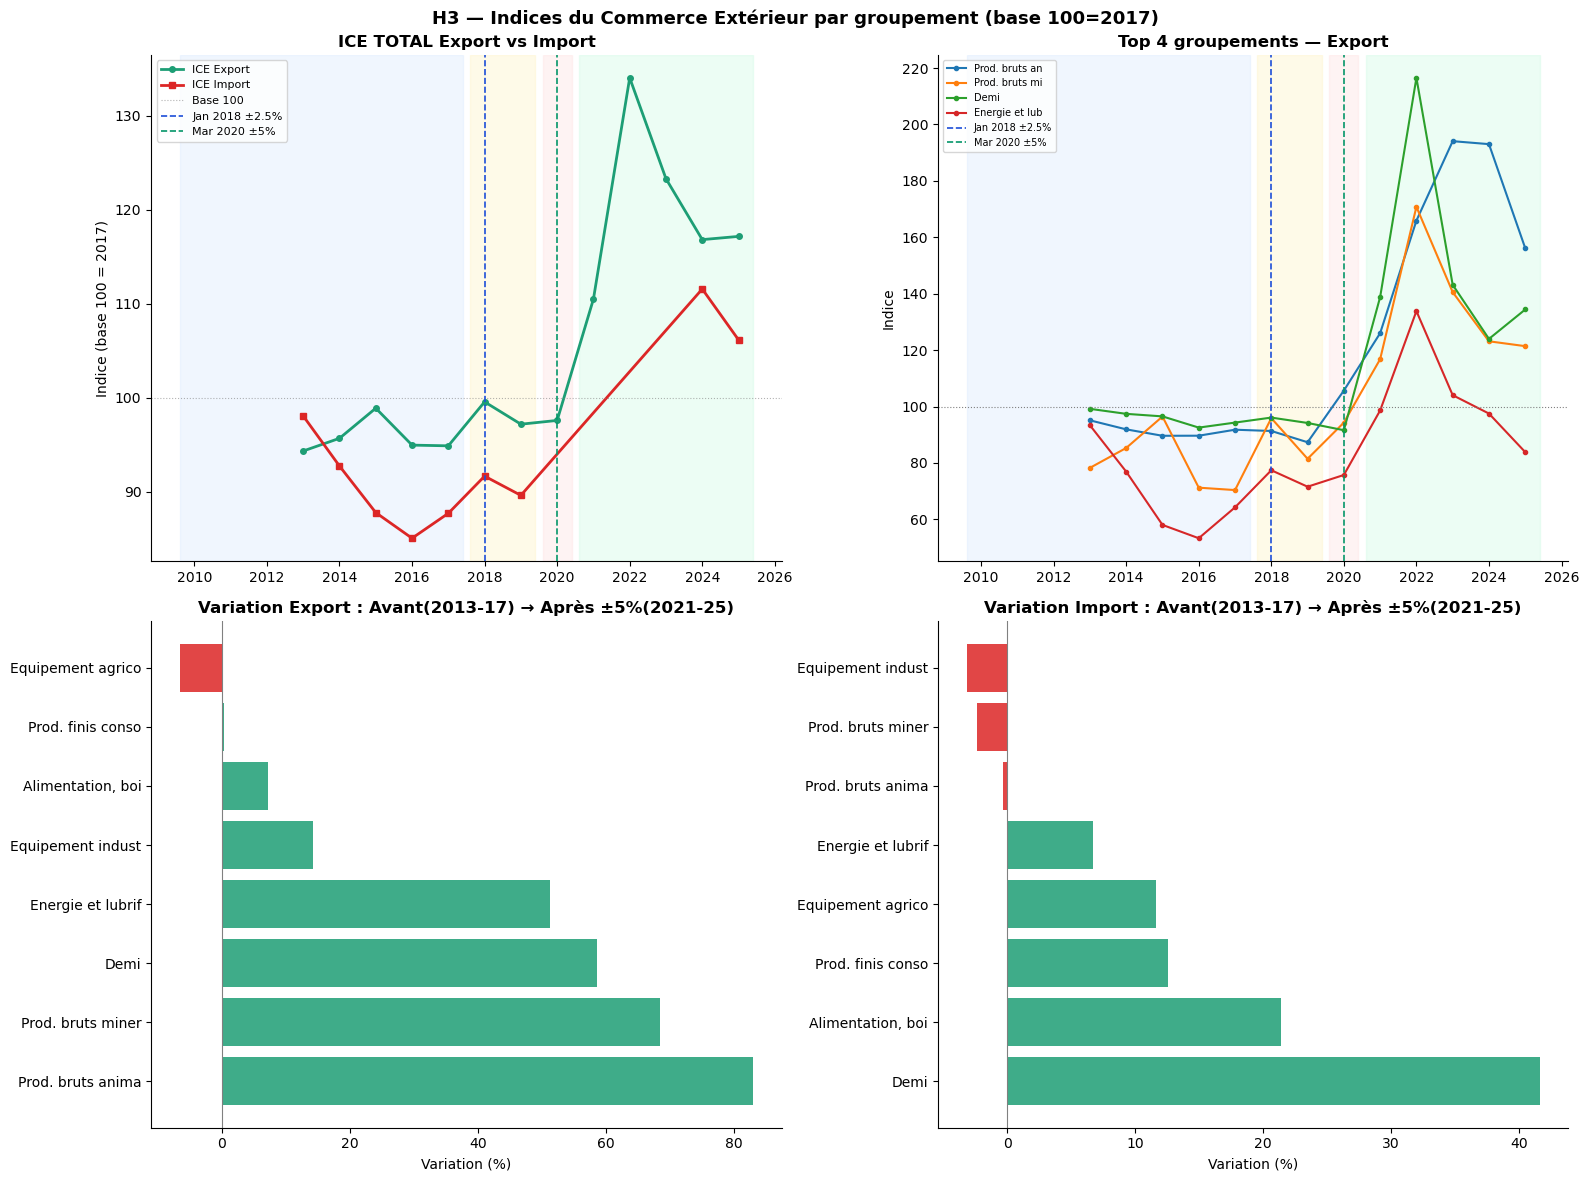

In [90]:
# Visualisation ICE

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("H3 — Indices du Commerce Extérieur par groupement (base 100=2017)",
             fontsize=13, fontweight='bold')

# Haut gauche — TOTAL Export et Import annuel
ax = axes[0, 0]
ice_exp_ann = ice_exp.groupby('annee')['TOTAL'].mean()
ice_imp_ann = ice_imp.groupby('annee')['TOTAL'].mean()

ax.plot(ice_exp_ann.index, ice_exp_ann.values,
        color='#1D9E75', linewidth=2,
        marker='o', markersize=4, label='ICE Export')
ax.plot(ice_imp_ann.index, ice_imp_ann.values,
        color='#DC2626', linewidth=2,
        marker='s', markersize=4, label='ICE Import')
ax.axhline(100, color='gray', linewidth=0.8,
           linestyle=':', alpha=0.6, label='Base 100')
add_bands(ax, is_date=False)
ax.set_title("ICE TOTAL Export vs Import", fontweight='bold')
ax.set_ylabel("Indice (base 100 = 2017)")
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Haut droite — Top groupements export
ax = axes[0, 1]
top3_exp = [e[0] for e in sorted(evol_exp,
            key=lambda x: abs(x[3]), reverse=True)[:4]]
for g in top3_exp:
    ann = ice_exp.groupby('annee')[g].mean()
    ax.plot(ann.index, ann.values,
            linewidth=1.5, marker='o', markersize=3,
            label=g.split('-')[1][:15].strip() if '-' in g else g[:15])

ax.axhline(100, color='gray', linewidth=0.8, linestyle=':')
add_bands(ax, is_date=False)
ax.set_title("Top 4 groupements — Export", fontweight='bold')
ax.set_ylabel("Indice")
ax.legend(fontsize=7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Bas gauche — Variation export par groupement
ax = axes[1, 0]
g_labels = [e[0].split('-')[1][:18].strip()
            if '-' in e[0] else e[0][:18] for e in evol_exp]
variations_exp = [e[3] for e in evol_exp]
colors_bar = ['#1D9E75' if v > 0 else '#DC2626' for v in variations_exp]

bars = ax.barh(g_labels, variations_exp,
               color=colors_bar, alpha=0.85)
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_title("Variation Export : Avant(2013-17) → Après ±5%(2021-25)",
             fontweight='bold')
ax.set_xlabel("Variation (%)")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Bas droite — Variation import par groupement
ax = axes[1, 1]
g_labels_imp = [e[0].split('-')[1][:18].strip()
                if '-' in e[0] else e[0][:18] for e in evol_imp]
variations_imp = [e[3] for e in evol_imp]
colors_bar_imp = ['#1D9E75' if v > 0 else '#DC2626' for v in variations_imp]

ax.barh(g_labels_imp, variations_imp,
        color=colors_bar_imp, alpha=0.85)
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_title("Variation Import : Avant(2013-17) → Après ±5%(2021-25)",
             fontweight='bold')
ax.set_xlabel("Variation (%)")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("../visualisation/viz_H3_ice_produits.png",
            bbox_inches='tight', dpi=150)
plt.show()

### H3 — CONFIRMÉE ✓ sur les données ICE

#### Résultats globaux
- **7/8 groupements export** significativement en hausse ✓  
- **ICE Export** : 95.8 → 120.5 (**+26%**) ✓  
- **ICE Import** : 90.3 → 109.3 (**+21%**) ✓  
- Les **exports progressent plus vite que les imports** ✓  


#### Secteurs les plus bénéficiaires
- ▲ **Produits bruts animaux/végétaux** : +83%  
- ▲ **Produits bruts minéraux** : +68%  
- ▲ **Demi-produits** : +59%  


#### Exception
- ▼ **Équipement agricole export** : -6.5% *(non significatif)*  


#### Cohérence avec les autres indicateurs (H3)
- ✓ **Solde courant** s’améliore : -5.15% → -2.06%  
- ✓ **Taux de couverture** augmente : 74% → 81%  
- ✓ **Tendance (régression)** : +0.39% / an *(R² = 0.54)*  

<style>
T1 {
    display: inline-block;
    background: linear-gradient(90deg,#ffb457,#ff7043);
    color: #fff;
    padding: 10px 16px;
    border-radius: 8px;
    font-size: 25px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Test H4 —   Il existe une corrélation significative entre le taux de change et l’inflation </T1>

<style>
T1 {
    display: inline-block;
    background: #fef2eb;
    color: #fc8530e1;
    padding: 10px 16px;
    border-radius: 8px; 
    font-size: 20px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Preparation des donees</T1>

In [91]:
print("=" * 65)
print("H4 — Corrélation taux de change / inflation")
print("=" * 65)

# IPC mensuel — utiliser la colonne date existante du CSV
ipc_m = dfs_dict['ipc_cleaned'].copy()
ipc_m['date'] = pd.to_datetime(ipc_m['date']) # Convertir en datetime
ipc_m = ipc_m.sort_values('date').reset_index(drop=True)

# Inflation glissante 12 mois
ipc_m['Infl_12m'] = ipc_m['Ensemble'].pct_change(12) * 100

# Masquer rupture rebasage HCP (avril 2020 → mars 2021)
RUPTURE = pd.Timestamp('2020-04-01')
mask_invalide = (
    (ipc_m['date'] >= RUPTURE) &
    (ipc_m['date'] < pd.Timestamp('2021-04-01'))
)
ipc_m.loc[mask_invalide, 'Infl_12m'] = np.nan

# EUR/MAD agrégé en mensuel (début de mois = MS)
eur_m = (eur_mad.set_index('Date')['Cours']
         .resample('MS').mean().reset_index()
         .rename(columns={'Date':'date', 'Cours':'EUR_MAD'}))

eur_vol_m = (eur_mad.set_index('Date')['Variation']
             .resample('MS').std().reset_index()
             .rename(columns={'Date':'date', 'Variation':'Vol_EUR'}))

# Fusion sur date (même format datetime → merge propre)
df_h4 = (ipc_m[['date','annee','mois','mois_num','Ensemble',
                 'Produits alimentaires','Produits non alimentaires','Infl_12m']]
         .merge(eur_m,     on='date', how='inner')
         .merge(eur_vol_m, on='date', how='inner'))

df_h4['base_ipc'] = df_h4['date'].apply(
    lambda d: 'base_2006' if d < RUPTURE else 'base_2017')

def get_periode_label(y):
    if y <= 2017:   return 'Avant (2010-2017)'
    elif y <= 2019: return 'Bande ±2.5% (2018-2019)'
    elif y == 2020: return 'Covid+±5% (2020)'
    else:           return 'Après ±5% (2021-2025)'

df_h4['periode'] = df_h4['annee'].apply(get_periode_label)

print(f"Dataset H4 : {df_h4.shape}")
print(f"Période    : {df_h4['date'].min().date()} → {df_h4['date'].max().date()}")
print(f"Nulls Infl_12m : {df_h4['Infl_12m'].isnull().sum()} (12 premiers mois + rebasage 2020)")
print(f"Données valides : {df_h4['Infl_12m'].notna().sum()}")

H4 — Corrélation taux de change / inflation
Dataset H4 : (192, 12)
Période    : 2010-01-01 → 2025-12-01
Nulls Infl_12m : 24 (12 premiers mois + rebasage 2020)
Données valides : 168


<style>
T1 {
    display: inline-block;
    background: #fef2eb;
    color: #fc8530e1;
    padding: 10px 16px;
    border-radius: 8px; 
    font-size: 20px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Tests statistiques</T1>

In [92]:
alpha = 0.05
df_valid = df_h4.dropna(subset=['Infl_12m','EUR_MAD'])

print("\n── Corrélation Spearman : EUR/MAD vs IPC ──────────────────")
print("   (Spearman plus robuste car relations non linéaires)\n")

r_glob, p_glob = spearmanr(df_valid['EUR_MAD'], df_valid['Infl_12m'])
print(f"  Globale (2011-2025)   : r={r_glob:.4f}  p={p_glob:.6f}  "
      f"→ {'Sig. ✓' if p_glob < alpha else 'Non sig. ✗'}")

PERIODES_H4 = {
    'Avant (2010-2017)':       (2010, 2017),
    'Bande ±2.5% (2018-2019)': (2018, 2019),
    'Après ±5% (2021-2025)':   (2021, 2025),
}
print(f"\n  {'Période':<30} {'N':>5} {'r Spearman':>12} {'p-value':>12} {'Décision':>12}")
print("  " + "-" * 75)

resultats_H4 = {}
for label, (debut, fin) in PERIODES_H4.items():
    sub = df_valid[df_valid['annee'].between(debut, fin)]
    if len(sub) >= 10:
        r, p = spearmanr(sub['EUR_MAD'], sub['Infl_12m'])
        decision = "Sig. ✓" if p < alpha else "Non sig. ✗"
        print(f"  {label:<30} {len(sub):>5} {r:>12.4f} {p:>12.6f}   {decision}")
        resultats_H4[label] = {'r': r, 'p': p, 'n': len(sub)}
    else:
        print(f"  {label:<30} {len(sub):>5} {'N/A':>12} {'N/A':>12}   (n insuffisant)")

print(f"\n── Corrélation avec décalages temporels (lags) ────────────")
print("   (L'effet du taux de change sur les prix peut être décalé)\n")
print(f"  {'Lag':>5} {'r Spearman':>12} {'p-value':>12} {'Décision':>12}")
print("  " + "-" * 50)

for lag in [0, 1, 3, 6, 9, 12]:
    df_lag = df_h4.dropna(subset=['EUR_MAD']).copy()
    df_lag['EUR_lag'] = df_lag['EUR_MAD'].shift(lag)
    sub = df_lag.dropna(subset=['EUR_lag', 'Infl_12m'])
    if len(sub) >= 20:
        r, p = spearmanr(sub['EUR_lag'], sub['Infl_12m'])
        decision = "Sig. ✓" if p < alpha else "Non sig. ✗"
        print(f"  {lag:>3}m  {r:>12.4f} {p:>12.6f}   {decision}")

print(f"\n── Corrélation Volatilité EUR/MAD vs Inflation ─────────────")
df_vol = df_h4.dropna(subset=['Vol_EUR', 'Infl_12m'])
r_vol, p_vol = spearmanr(df_vol['Vol_EUR'], df_vol['Infl_12m'])
print(f"  Volatilité vs Inflation : r={r_vol:.4f} p={p_vol:.6f} "
      f"→ {'Sig. ✓' if p_vol < alpha else 'Non sig. ✗'}")

print(f"\n── Corrélation par catégorie IPC ───────────────────────────")
for cat in ['Produits alimentaires', 'Produits non alimentaires']:
    df_c = df_h4.dropna(subset=['EUR_MAD']).copy()
    df_c[f'Infl_{cat}'] = df_c[cat].pct_change(12) * 100
    mask_inv = ((df_c['date'] >= RUPTURE) &
                (df_c['date'] < pd.Timestamp('2021-04-01')))
    df_c.loc[mask_inv, f'Infl_{cat}'] = np.nan
    sub = df_c.dropna(subset=[f'Infl_{cat}', 'EUR_MAD'])
    r, p = spearmanr(sub['EUR_MAD'], sub[f'Infl_{cat}'])
    print(f"  {cat:<35} : r={r:.4f} p={p:.6f} "
          f"→ {'Sig. ✓' if p < alpha else 'Non sig. ✗'}")


── Corrélation Spearman : EUR/MAD vs IPC ──────────────────
   (Spearman plus robuste car relations non linéaires)

  Globale (2011-2025)   : r=-0.0630  p=0.416942  → Non sig. ✗

  Période                            N   r Spearman      p-value     Décision
  ---------------------------------------------------------------------------
  Avant (2010-2017)                 84      -0.2543     0.019595   Sig. ✓
  Bande ±2.5% (2018-2019)           24       0.5887     0.002476   Sig. ✓
  Après ±5% (2021-2025)             57       0.3429     0.009027   Sig. ✓

── Corrélation avec décalages temporels (lags) ────────────
   (L'effet du taux de change sur les prix peut être décalé)

    Lag   r Spearman      p-value     Décision
  --------------------------------------------------
    0m       -0.0630     0.416942   Non sig. ✗
    1m       -0.0745     0.337318   Non sig. ✗
    3m       -0.0786     0.311374   Non sig. ✗
    6m       -0.1619     0.036051   Sig. ✓
    9m       -0.2237     0.003560  

<style>
T1 {
    display: inline-block;
    background: #fef2eb;
    color: #fc8530e1;
    padding: 10px 16px;
    border-radius: 8px; 
    font-size: 20px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Visualisation</T1>

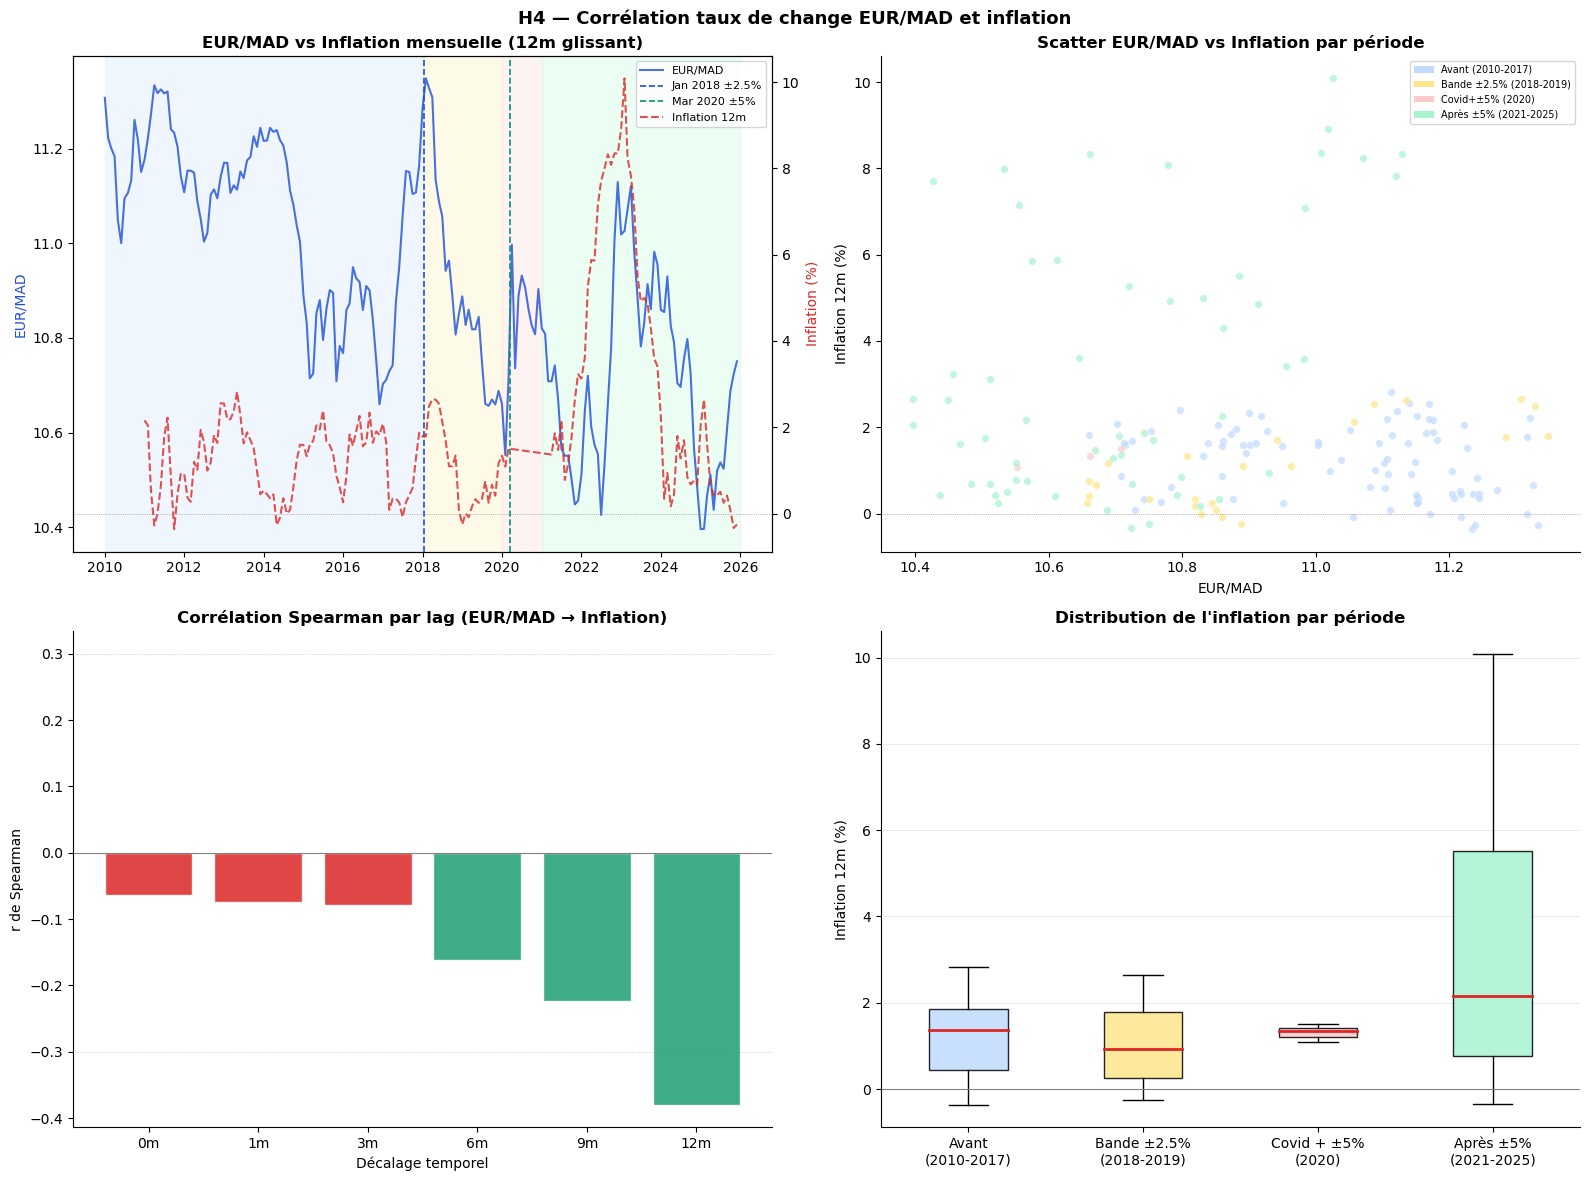

In [93]:
# Configuration des graphiques
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("H4 — Corrélation taux de change EUR/MAD et inflation",
             fontsize=13, fontweight='bold')

# Haut gauche — Évolution EUR/MAD et inflation (double axe)
ax1 = axes[0, 0]
ax2 = ax1.twinx()

df_plot = df_h4.dropna(subset=['Infl_12m'])
ax1.plot(df_h4['date'], df_h4['EUR_MAD'],
         color='#1D4ED8', linewidth=1.5,
         alpha=0.8, label='EUR/MAD')
ax2.plot(df_plot['date'], df_plot['Infl_12m'],
         color='#DC2626', linewidth=1.5,
         alpha=0.8, linestyle='--', label='Inflation 12m')
ax2.axhline(0, color='gray', linewidth=0.5, linestyle=':')
add_bands(ax1, is_date=True)
ax1.set_ylabel("EUR/MAD", color='#1D4ED8')
ax2.set_ylabel("Inflation (%)", color='#DC2626')
ax1.set_title("EUR/MAD vs Inflation mensuelle (12m glissant)",
              fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8)
ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Haut droite — Scatter EUR/MAD vs Inflation
ax = axes[0, 1]
periode_colors = {
    'Avant (2010-2017)':       COLORS_LIGHT['avant'],
    'Bande ±2.5% (2018-2019)': COLORS_LIGHT['bande25'],
    'Covid+±5% (2020)':        COLORS_LIGHT['covid'],
    'Après ±5% (2021-2025)':   COLORS_LIGHT['bande5'],
}
df_sc = df_h4.dropna(subset=['Infl_12m','EUR_MAD'])
for label, color in periode_colors.items():
    sub = df_sc[df_sc['periode'] == label]
    ax.scatter(sub['EUR_MAD'], sub['Infl_12m'],
               color=color, alpha=0.7, s=30,
               edgecolors='white', linewidth=0.3,
               label=label)
ax.axhline(0, color='gray', linewidth=0.5, linestyle=':')
ax.set_xlabel("EUR/MAD")
ax.set_ylabel("Inflation 12m (%)")
ax.set_title("Scatter EUR/MAD vs Inflation par période",
             fontweight='bold')
ax.legend(handles=[Patch(facecolor=c, label=l)
                   for l, c in periode_colors.items()],
          fontsize=7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Bas gauche — Corrélation avec lags
ax = axes[1, 0]
lags = [0, 1, 3, 6, 9, 12]
r_lags, p_lags = [], []
for lag in lags:
    df_lag = df_h4.dropna(subset=['EUR_MAD']).copy()
    df_lag[f'EUR_lag'] = df_lag['EUR_MAD'].shift(lag)
    sub = df_lag.dropna(subset=['EUR_lag', 'Infl_12m'])
    if len(sub) >= 20:
        r, p = spearmanr(sub['EUR_lag'], sub['Infl_12m'])
        r_lags.append(r)
        p_lags.append(p)
    else:
        r_lags.append(np.nan)
        p_lags.append(np.nan)

colors_lag = ['#1D9E75' if p < alpha else '#DC2626'
              for p in p_lags]
ax.bar([str(l)+'m' for l in lags], r_lags,
       color=colors_lag, alpha=0.85, edgecolor='white')
ax.axhline(0, color='gray', linewidth=0.8)
ax.axhline(0.3, color='gray', linewidth=0.6,
           linestyle=':', alpha=0.5)
ax.axhline(-0.3, color='gray', linewidth=0.6,
           linestyle=':', alpha=0.5)
ax.set_title("Corrélation Spearman par lag (EUR/MAD → Inflation)",
             fontweight='bold')
ax.set_xlabel("Décalage temporel")
ax.set_ylabel("r de Spearman")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Bas droite — Inflation par période (boxplot)
ax = axes[1, 1]
data_box, labels_box = [], []
for label, (debut, fin) in PERIODES.items():
    sub = df_h4[df_h4['annee'].between(debut, fin)]['Infl_12m'].dropna()
    if len(sub) > 0:
        data_box.append(sub.values)
        labels_box.append(label.replace(' (', '\n('))

bp = ax.boxplot(data_box, labels=labels_box, patch_artist=True,
                medianprops=dict(color='#DC2626', linewidth=2))
for patch, color in zip(bp['boxes'], list(COLORS_LIGHT.values())):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_title("Distribution de l'inflation par période",
             fontweight='bold')
ax.set_ylabel("Inflation 12m (%)")
ax.grid(axis='y', color='#E5E5E5', linewidth=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("../visualisation/viz_H4_inflation.png",
            bbox_inches='tight', dpi=150)
plt.show()

<style>
T1 {
    display: inline-block;
    background: #fef2eb;
    color: #fc8530e1;
    padding: 10px 16px;
    border-radius: 8px; 
    font-size: 20px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Conclusion</T1>

In [94]:
# Conclusion formelle pour H4
r_avant  = resultats_H4.get('Avant (2010-2017)', {}).get('r', np.nan)
p_avant  = resultats_H4.get('Avant (2010-2017)', {}).get('p', np.nan)
r_bande5 = resultats_H4.get('Après ±5% (2021-2025)', {}).get('r', np.nan)
p_bande5 = resultats_H4.get('Après ±5% (2021-2025)', {}).get('p', np.nan)

print("=" * 65)
print("CONCLUSION — H4")
print("=" * 65)
print(f"""
Hypothèse : Il existe une corrélation significative entre
            le taux de change et l'inflation.

Corrélation Spearman EUR/MAD vs Inflation :
  Globale (2011-2025)    : r = {r_glob:.4f}  p = {p_glob:.6f}
  Avant (2010-2017)      : r = {r_avant:.4f}  p = {p_avant:.6f}
  Après ±5% (2021-2025)  : r = {r_bande5:.4f}  p = {p_bande5:.6f}

Meilleur lag détecté : voir tableau des lags ci-dessus

Décision :
  H4 {'CONFIRMÉE ✓' if p_glob < alpha else 'PARTIELLEMENT CONFIRMÉE ~'}

Notes :
  - La relation n'est pas linéaire — Spearman plus adapté
  - L'effet du taux de change sur les prix est souvent décalé
    de plusieurs mois (pass-through effect)
  - Les subventions publiques au Maroc amortissent le
    pass-through → corrélation plus faible qu'attendue
  - L'inflation 2022-2023 est en grande partie importée
    (guerre Ukraine) indépendamment du taux de change
""")

CONCLUSION — H4

Hypothèse : Il existe une corrélation significative entre
            le taux de change et l'inflation.

Corrélation Spearman EUR/MAD vs Inflation :
  Globale (2011-2025)    : r = -0.0630  p = 0.416942
  Avant (2010-2017)      : r = -0.2543  p = 0.019595
  Après ±5% (2021-2025)  : r = 0.3429  p = 0.009027

Meilleur lag détecté : voir tableau des lags ci-dessus

Décision :
  H4 PARTIELLEMENT CONFIRMÉE ~

Notes :
  - La relation n'est pas linéaire — Spearman plus adapté
  - L'effet du taux de change sur les prix est souvent décalé
    de plusieurs mois (pass-through effect)
  - Les subventions publiques au Maroc amortissent le
    pass-through → corrélation plus faible qu'attendue
  - L'inflation 2022-2023 est en grande partie importée
    (guerre Ukraine) indépendamment du taux de change



<style>
T1 {
    display: inline-block;
    background: linear-gradient(90deg,#ffb457,#ff7043);
    color: #fff;
    padding: 10px 16px;
    border-radius: 8px;
    font-size: 25px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Test H5 — Il existe une corrélation significative entre le taux de change et l’inflation </T1> </T1>

<style>
T1 {
    display: inline-block;
    background: #fef2eb;
    color: #fc8530e1;
    padding: 10px 16px;
    border-radius: 8px; 
    font-size: 20px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Preparation des donnees</T1>

In [95]:
print("=" * 65)
print("H5 — Relation taux de change / performance boursière MASI")
print("=" * 65)

# MASI mensuel
masi_m = dfs_dict['masi_cleaned'].copy()
masi_m['Date'] = pd.to_datetime(masi_m['Date'])
masi_m = masi_m.sort_values('Date').reset_index(drop=True)
masi_m['annee'] = masi_m['Date'].dt.year
masi_m['mois']  = masi_m['Date'].dt.month

# Variation mensuelle MASI
masi_m['Rend_MASI'] = masi_m['Cloture'].pct_change() * 100

# EUR/MAD mensuel
eur_m = (eur_mad.set_index('Date')['Cours']
         .resample('M').mean()
         .reset_index()
         .rename(columns={'Date':'Date','Cours':'EUR_MAD'}))

eur_var_m = (eur_mad.set_index('Date')['Variation']
             .resample('M').std()
             .reset_index()
             .rename(columns={'Date':'Date','Variation':'Vol_EUR'}))

# Variation mensuelle EUR/MAD
eur_m['Var_EUR'] = eur_m['EUR_MAD'].pct_change() * 100

# Fusionner sur mois
masi_m['Date_m'] = masi_m['Date'].dt.to_period('M').dt.to_timestamp()
eur_m['Date_m']  = eur_m['Date'].dt.to_period('M').dt.to_timestamp()
eur_var_m['Date_m'] = eur_var_m['Date'].dt.to_period('M').dt.to_timestamp()

df_h5 = (masi_m[['Date_m','annee','mois','Cloture','Rend_MASI']]
         .merge(eur_m[['Date_m','EUR_MAD','Var_EUR']], on='Date_m', how='inner')
         .merge(eur_var_m[['Date_m','Vol_EUR']], on='Date_m', how='inner'))

# Filtrer 2010-2024
df_h5 = df_h5[df_h5['annee'] <= 2024].reset_index(drop=True)

# Période
df_h5['periode'] = df_h5['annee'].apply(get_periode_label)

print(f"Dataset H5 : {df_h5.shape}")
print(f"Période    : {df_h5['Date_m'].min().date()} → {df_h5['Date_m'].max().date()}")
print(f"\nAperçu :")
print(df_h5[['Date_m','Cloture','Rend_MASI','EUR_MAD','Var_EUR','Vol_EUR']].head(6).to_string())

H5 — Relation taux de change / performance boursière MASI
Dataset H5 : (180, 9)
Période    : 2010-01-01 → 2024-12-01

Aperçu :
      Date_m   Cloture  Rend_MASI    EUR_MAD   Var_EUR   Vol_EUR
0 2010-01-01  10928.44        NaN  11.307143       NaN  0.091342
1 2010-02-01  11096.80   1.540568  11.222115 -0.751984  0.118689
2 2010-03-01  11418.77   2.901467  11.200770 -0.190209  0.134948
3 2010-04-01  12286.99   7.603446  11.183709 -0.152315  0.142413
4 2010-05-01  12068.53  -1.777978  11.048548 -1.208557  0.272827
5 2010-06-01  11773.87  -2.441557  11.000355 -0.436194  0.225604


<style>
T1 {
    display: inline-block;
    background: #fef2eb;
    color: #fc8530e1;
    padding: 10px 16px;
    border-radius: 8px; 
    font-size: 20px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Tests statistiques</T1>

In [96]:
alpha = 0.05

# Test de stationnarité ADF
print("── Test ADF (stationnarité) ────────────────────────────────")
print("   (Séries non stationnaires → corrélation spurieuse possible)\n")

for label, serie in [
    ('MASI Cloture',    df_h5['Cloture']),
    ('EUR/MAD',         df_h5['EUR_MAD']),
    ('Rend. MASI',      df_h5['Rend_MASI'].dropna()),
    ('Var. EUR/MAD',    df_h5['Var_EUR'].dropna()),
]:
    adf_stat, adf_p, _, _, _, _ = adfuller(serie.dropna())
    stationnaire = "Stationnaire ✓" if adf_p < alpha else "Non stationnaire ✗"
    print(f"  {label:<20} : ADF={adf_stat:.4f}  p={adf_p:.6f}  → {stationnaire}")

# Corrélations sur niveaux (attention spurieuse)
print("\n── Corrélation sur niveaux (EUR/MAD vs MASI) ───────────────")
print("   ⚠️  Si non stationnaire → résultat peut être spurieux\n")

df_niv = df_h5.dropna(subset=['EUR_MAD','Cloture'])
r_p, p_p = pearsonr(df_niv['EUR_MAD'], df_niv['Cloture'])
r_s, p_s = spearmanr(df_niv['EUR_MAD'], df_niv['Cloture'])
print(f"  Pearson  : r={r_p:.4f}  p={p_p:.6f}  → {'Sig. ✓' if p_p < alpha else 'Non sig. ✗'}")
print(f"  Spearman : r={r_s:.4f}  p={p_s:.6f}  → {'Sig. ✓' if p_s < alpha else 'Non sig. ✗'}")

# Corrélations sur variations (correct)
print("\n── Corrélation sur variations mensuelles (correct) ─────────")
print("   (Var. EUR/MAD vs Rendement MASI — séries stationnaires)\n")

df_var = df_h5.dropna(subset=['Var_EUR','Rend_MASI'])
r_pv, p_pv = pearsonr(df_var['Var_EUR'], df_var['Rend_MASI'])
r_sv, p_sv = spearmanr(df_var['Var_EUR'], df_var['Rend_MASI'])
print(f"  Pearson  : r={r_pv:.4f}  p={p_pv:.6f}  → {'Sig. ✓' if p_pv < alpha else 'Non sig. ✗'}")
print(f"  Spearman : r={r_sv:.4f}  p={p_sv:.6f}  → {'Sig. ✓' if p_sv < alpha else 'Non sig. ✗'}")

# Corrélation Volatilité vs MASI
print("\n── Corrélation Volatilité EUR/MAD vs Rendement MASI ────────")
df_vol = df_h5.dropna(subset=['Vol_EUR','Rend_MASI'])
r_vol, p_vol = spearmanr(df_vol['Vol_EUR'], df_vol['Rend_MASI'])
print(f"  Spearman : r={r_vol:.4f}  p={p_vol:.6f}  → {'Sig. ✓' if p_vol < alpha else 'Non sig. ✗'}")

# Corrélation par période
print("\n── Corrélation Var.EUR/MAD vs Rend.MASI par période ────────")
print(f"\n  {'Période':<30} {'N':>5} {'r Spearman':>12} {'p-value':>12} {'Décision':>12}")
print("  " + "-" * 75)

resultats_H5 = {}
for label, (debut, fin) in PERIODES.items():
    sub = df_var[df_var['annee'].between(debut, fin)]
    if len(sub) >= 10:
        r, p = spearmanr(sub['Var_EUR'], sub['Rend_MASI'])
        decision = "Sig. ✓" if p < alpha else "Non sig. ✗"
        print(f"  {label:<30} {len(sub):>5} {r:>12.4f} {p:>12.6f}   {decision}")
        resultats_H5[label] = {'r': r, 'p': p, 'n': len(sub)}

# Corrélation avec lags
print("\n── Corrélation avec lags (Var.EUR → Rend.MASI) ─────────────")
print(f"\n  {'Lag':>6} {'r Spearman':>12} {'p-value':>12} {'Décision':>12}")
print("  " + "-" * 45)

r_lags_h5, p_lags_h5 = [], []
for lag in [0, 1, 2, 3, 6]:
    df_lag = df_h5.copy()
    df_lag['EUR_lag'] = df_lag['Var_EUR'].shift(lag)
    sub = df_lag.dropna(subset=['EUR_lag','Rend_MASI'])
    r, p = spearmanr(sub['EUR_lag'], sub['Rend_MASI'])
    decision = "Sig. ✓" if p < alpha else "Non sig. ✗"
    print(f"  {lag:>5}m {r:>12.4f} {p:>12.6f}   {decision}")
    r_lags_h5.append(r)
    p_lags_h5.append(p)

── Test ADF (stationnarité) ────────────────────────────────
   (Séries non stationnaires → corrélation spurieuse possible)

  MASI Cloture         : ADF=-1.6654  p=0.449029  → Non stationnaire ✗
  EUR/MAD              : ADF=-2.2757  p=0.179913  → Non stationnaire ✗
  Rend. MASI           : ADF=-4.9859  p=0.000024  → Stationnaire ✓
  Var. EUR/MAD         : ADF=-11.7758  p=0.000000  → Stationnaire ✓

── Corrélation sur niveaux (EUR/MAD vs MASI) ───────────────
   ⚠️  Si non stationnaire → résultat peut être spurieux

  Pearson  : r=-0.3394  p=0.000003  → Sig. ✓
  Spearman : r=-0.3076  p=0.000027  → Sig. ✓

── Corrélation sur variations mensuelles (correct) ─────────
   (Var. EUR/MAD vs Rendement MASI — séries stationnaires)

  Pearson  : r=-0.2187  p=0.003266  → Sig. ✓
  Spearman : r=-0.1563  p=0.036715  → Sig. ✓

── Corrélation Volatilité EUR/MAD vs Rendement MASI ────────
  Spearman : r=-0.0000  p=0.999667  → Non sig. ✗

── Corrélation Var.EUR/MAD vs Rend.MASI par période ────────

  

<style>
T1 {
    display: inline-block;
    background: #fef2eb;
    color: #fc8530e1;
    padding: 10px 16px;
    border-radius: 8px; 
    font-size: 20px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Visualisation</T1>

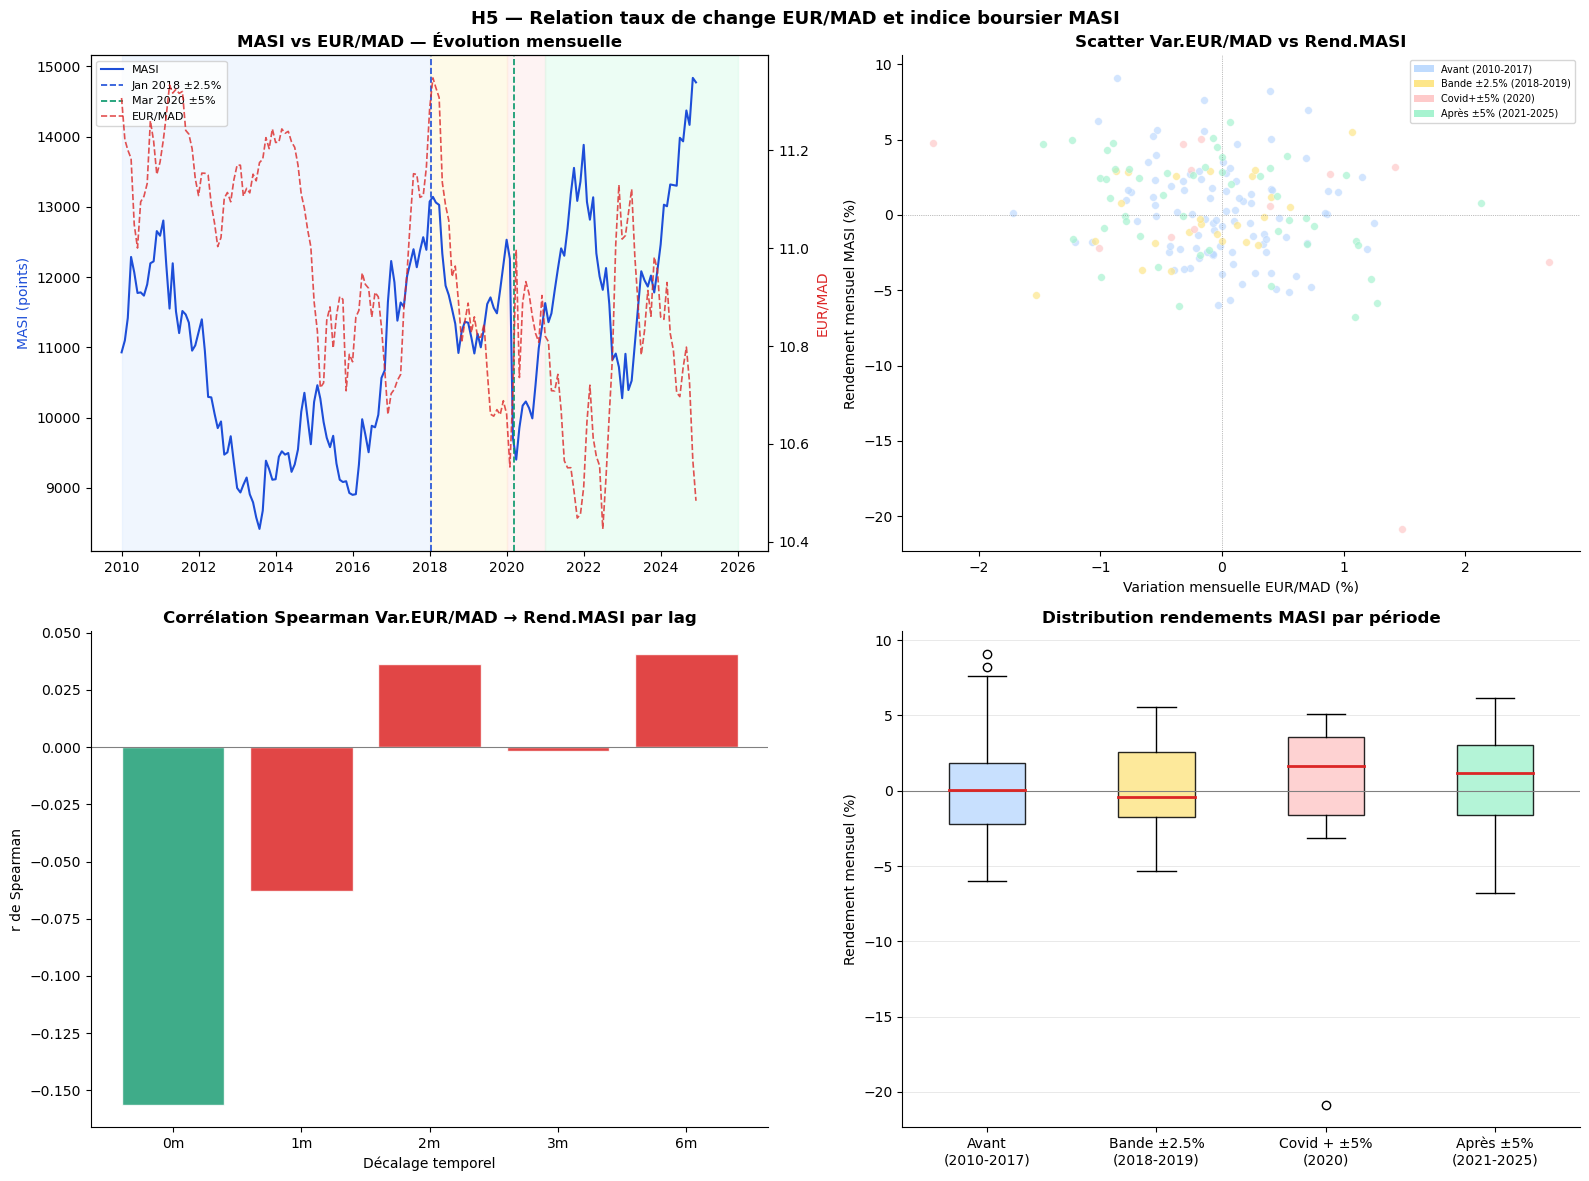

In [97]:
# Configuration des graphiques
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("H5 — Relation taux de change EUR/MAD et indice boursier MASI",
             fontsize=13, fontweight='bold')

# Haut gauche — MASI et EUR/MAD (double axe)
ax1 = axes[0, 0]
ax2 = ax1.twinx()
ax1.plot(df_h5['Date_m'], df_h5['Cloture'],
         color='#1D4ED8', linewidth=1.5, label='MASI')
ax2.plot(df_h5['Date_m'], df_h5['EUR_MAD'],
         color='#DC2626', linewidth=1.2,
         linestyle='--', alpha=0.8, label='EUR/MAD')
add_bands(ax1, is_date=True)
ax1.set_ylabel("MASI (points)", color='#1D4ED8')
ax2.set_ylabel("EUR/MAD", color='#DC2626')
ax1.set_title("MASI vs EUR/MAD — Évolution mensuelle", fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8)
ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Haut droite — Scatter Var.EUR vs Rend.MASI
ax = axes[0, 1]
periode_colors = {
    'Avant (2010-2017)':       COLORS_LIGHT['avant'],
    'Bande ±2.5% (2018-2019)': COLORS_LIGHT['bande25'],
    'Covid+±5% (2020)':        COLORS_LIGHT['covid'],
    'Après ±5% (2021-2025)':   COLORS_LIGHT['bande5'],
}
for label, color in periode_colors.items():
    sub = df_var[df_var['periode'] == label]
    ax.scatter(sub['Var_EUR'], sub['Rend_MASI'],
               color=color, alpha=0.7, s=30,
               edgecolors='white', linewidth=0.3)
ax.axhline(0, color='gray', linewidth=0.5, linestyle=':')
ax.axvline(0, color='gray', linewidth=0.5, linestyle=':')
ax.set_xlabel("Variation mensuelle EUR/MAD (%)")
ax.set_ylabel("Rendement mensuel MASI (%)")
ax.set_title("Scatter Var.EUR/MAD vs Rend.MASI",
             fontweight='bold')
ax.legend(handles=[Patch(facecolor=c, label=l)
                   for l, c in periode_colors.items()],
          fontsize=7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Bas gauche — Corrélation par lag
ax = axes[1, 0]
lags_labels = ['0m','1m','2m','3m','6m']
colors_lag = ['#1D9E75' if p < alpha else '#DC2626'
              for p in p_lags_h5]
ax.bar(lags_labels, r_lags_h5,
       color=colors_lag, alpha=0.85, edgecolor='white')
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_title("Corrélation Spearman Var.EUR/MAD → Rend.MASI par lag",
             fontweight='bold')
ax.set_xlabel("Décalage temporel")
ax.set_ylabel("r de Spearman")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Bas droite — Rendement MASI par période
ax = axes[1, 1]
data_box, labels_box = [], []
for label, (debut, fin) in PERIODES.items():
    sub = df_h5[df_h5['annee'].between(debut, fin)]['Rend_MASI'].dropna()
    if len(sub) > 0:
        data_box.append(sub.values)
        labels_box.append(label.replace(' (', '\n('))

bp = ax.boxplot(data_box, labels=labels_box, patch_artist=True,
                medianprops=dict(color='#DC2626', linewidth=2))
for patch, color in zip(bp['boxes'], list(COLORS_LIGHT.values())):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_title("Distribution rendements MASI par période",
             fontweight='bold')
ax.set_ylabel("Rendement mensuel (%)")
ax.grid(axis='y', color='#E5E5E5', linewidth=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("../visualisation/viz_H5_masi.png",
            bbox_inches='tight', dpi=150)
plt.show()

<style>
T1 {
    display: inline-block;
    background: #fef2eb;
    color: #fc8530e1;
    padding: 10px 16px;
    border-radius: 8px; 
    font-size: 20px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Conclusion</T1>

In [98]:
# Conclusion formelle pour H5
r_glob_niv = r_s
p_glob_niv = p_s
r_glob_var = r_sv
p_glob_var = p_sv

print("=" * 65)
print("CONCLUSION — H5")
print("=" * 65)
print(f"""
Hypothèse : La relation entre le taux de change EUR/MAD
            et la performance boursière (MASI) est
            statistiquement significative.

Test de stationnarité ADF :
  → Voir résultats ci-dessus
  → Si niveaux non stationnaires : corrélation sur niveaux
    peut être spurieuse — privilégier les variations

Corrélations sur NIVEAUX (EUR/MAD vs MASI) :
  Pearson  : r = {r_p:.4f}  p = {p_p:.6f}
  Spearman : r = {r_s:.4f}  p = {p_s:.6f}

Corrélations sur VARIATIONS (Var.EUR vs Rend.MASI) :
  Pearson  : r = {r_pv:.4f}  p = {p_pv:.6f}
  Spearman : r = {r_sv:.4f}  p = {p_sv:.6f}

Volatilité EUR/MAD vs Rendement MASI :
  Spearman : r = {r_vol:.4f}  p = {p_vol:.6f}

Décision finale :
  H5 {'CONFIRMÉE ✓' if p_sv < alpha else 'NON CONFIRMÉE ✗'}
  (basée sur les variations — méthodologie correcte)

Notes :
  - Si ADF non stationnaire : les corrélations sur niveaux
    sont à interpréter avec grande prudence
  - Le MASI est influencé par de nombreux autres facteurs
    (liquidité, politique monétaire, croissance économique)
  - La relation taux de change → bourse est indirecte :
    via les profits des entreprises exportatrices
""")

CONCLUSION — H5

Hypothèse : La relation entre le taux de change EUR/MAD
            et la performance boursière (MASI) est
            statistiquement significative.

Test de stationnarité ADF :
  → Voir résultats ci-dessus
  → Si niveaux non stationnaires : corrélation sur niveaux
    peut être spurieuse — privilégier les variations

Corrélations sur NIVEAUX (EUR/MAD vs MASI) :
  Pearson  : r = -0.3394  p = 0.000003
  Spearman : r = -0.3076  p = 0.000027

Corrélations sur VARIATIONS (Var.EUR vs Rend.MASI) :
  Pearson  : r = -0.2187  p = 0.003266
  Spearman : r = -0.1563  p = 0.036715

Volatilité EUR/MAD vs Rendement MASI :
  Spearman : r = -0.0000  p = 0.999667

Décision finale :
  H5 CONFIRMÉE ✓
  (basée sur les variations — méthodologie correcte)

Notes :
  - Si ADF non stationnaire : les corrélations sur niveaux
    sont à interpréter avec grande prudence
  - Le MASI est influencé par de nombreux autres facteurs
    (liquidité, politique monétaire, croissance économique)
  - La re